In [ ]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install --upgrade xee

In [ ]:
!pip install rasterioya

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 27.1 MB/s eta 0:00:00


In [ ]:
import geopandas as gpd
import rasterio
import glob
import pandas as pd
import numpy as np
from rasterio.plot import show
from rasterio.mask import mask
from shapely.geometry import Point
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm  # For progress tracking

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path1 = '/content/drive/MyDrive/Kamatira Model Data'
path2 = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/tree_ground_truths.geojson'
path3 = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson'
path4 = "/content/drive/MyDrive/Kamatira Model Data/2024_2025"
path5 = "/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM"
path6 = "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH"

In [ ]:
import glob
import os
# Search for .tif files while excluding DEM and Slope
tif_files = [file for file in glob.glob(os.path.join(path4, '*.tif'))]

print("Filtered raster files for multicollinearity test:")
for file in tif_files:
    print(file)

Filtered raster files for multicollinearity test:


In [ ]:
# Load the ground truth data
path_ground_truth = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/GCPs_combined1.geojson"
gdf_points = gpd.read_file(path_ground_truth)
gdf_points.tail(5)

,H,geometry
65853,23.047567,POINT (35.2122 1.26635)
65854,25.648767,POINT (35.1802 1.2603)
65855,22.435934,POINT (35.16451 1.26632)
65856,34.301666,POINT (35.18797 1.26003)
65857,28.270599,POINT (35.21035 1.26517)


In [ ]:
# Load the ground truth data
path_ground_truth = "/content/drive/MyDrive/Kamatira Model Data/shapeFiles/Kamatira_Fitted_Dense_Points.shp"
gdf_idw = gpd.read_file(path_ground_truth)
# Rename 'grid_code' to 'H'
gdf_idw = gdf_idw.rename(columns={"grid_code": "H"})

# Keep only 'H' and 'geometry' columns
gdf_idw = gdf_idw[["H", "geometry"]]
# Randomly sample 7000 points from gdf_points
gdf_sampled = gdf_idw.sample(n=100000, random_state=42).reset_index(drop=True)
# Preview the result
gdf_sampled.head()


,H,geometry
0,8.47569,POINT (35.23654 1.27336)
1,23.60200,POINT (35.22842 1.27032)
2,21.67550,POINT (35.16359 1.27917)
3,18.58200,POINT (35.1641 1.26305)
4,22.67320,POINT (35.22047 1.26643)


In [ ]:
gdf_sampled.head()

,H,geometry
0,8.47569,POINT (35.23654 1.27336)
1,23.60200,POINT (35.22842 1.27032)
2,21.67550,POINT (35.16359 1.27917)
3,18.58200,POINT (35.1641 1.26305)
4,22.67320,POINT (35.22047 1.26643)


In [ ]:
gdf_below_20 = gdf_sampled[gdf_sampled["H"] < 15]

# Display count and a sample
print(f"Number of points with H < 15: {len(gdf_below_20)}")
gdf_below_20.head()


Number of points with H < 15: 22276


,H,geometry
0,8.47569,POINT (35.23654 1.27336)
8,12.16030,POINT (35.21359 1.26049)
16,11.48970,POINT (35.22902 1.28786)
21,10.51950,POINT (35.23025 1.27471)
23,14.49540,POINT (35.20181 1.26597)


In [ ]:
import geopandas as gpd

# Merge (append) the two GeoDataFrames
gdf_merged = gpd.GeoDataFrame(pd.concat([gdf_below_20, gdf_points], ignore_index=True), crs=gdf_points.crs)

# Show result
print(f"Total number of merged points: {len(gdf_merged)}")
gdf_merged.head()


Total number of merged points: 88134


,H,geometry
0,8.47569,POINT (35.23654 1.27336)
1,12.16030,POINT (35.21359 1.26049)
2,11.48970,POINT (35.22902 1.28786)
3,10.51950,POINT (35.23025 1.27471)
4,14.49540,POINT (35.20181 1.26597)


In [ ]:
gdf_points=gdf_merged

In [ ]:
import pandas as pd

# Define the bins and labels
bins = [0, 10, 20, 30, 40, 50]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50']

# Cut 'H' into bins
gdf_points['H_bin'] = pd.cut(gdf_points['H'], bins=bins, labels=labels, right=True, include_lowest=True)

# Count how many points fall into each bin
h_bin_counts = gdf_points['H_bin'].value_counts().sort_index()

# Show the result
print(h_bin_counts)


H_bin
0-10      7345
11-20    15217
21-30    22206
31-40    42484
41-50      882
Name: count, dtype: int64


In [ ]:
import geopandas as gpd
import pandas as pd

# Ensure geometry is active
gdf_points = gdf_points.set_geometry("geometry")

# Define bins and sample sizes
sample_spec = {
      (0, 10):   7345,
      (11,20):  10217,
      (21, 30): 15206,
      (31, 40): 9571,
      (41,50):  882
}

sampled_frames = []

# Loop over the specified bins and sample sizes
for (low, high), size in sample_spec.items():
    subset = gdf_points[(gdf_points['H'] >= low) & (gdf_points['H'] <= high)]
    sample = subset.sample(n=min(size, len(subset)), random_state=42)
    sampled_frames.append(sample[["H", "geometry"]])  # Only keep 'H' and 'geometry'

# Combine all samples into one GeoDataFrame
gdf_sampled = pd.concat(sampled_frames, ignore_index=True)
gdf_sampled = gpd.GeoDataFrame(gdf_sampled, geometry="geometry")

# Display sample count by H range
print("Sampled point distribution by H bins:")
print(gdf_sampled["H"].groupby(pd.cut(gdf_sampled["H"], bins=[10, 20, 30, 40, 50])).count())

# Optional: Save to file
# gdf_sampled.to_file("sampled_points_by_H_range.geojson", driver="GeoJSON")


Sampled point distribution by H bins:
H
(10, 20]    10217
(20, 30]    15206
(30, 40]     9571
(40, 50]      375
Name: H, dtype: int64


<ipython-input-19-c0054cf79443>:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(gdf_sampled["H"].groupby(pd.cut(gdf_sampled["H"], bins=[10, 20, 30, 40, 50])).count())


In [ ]:
gdf_points=gdf_sampled
gdf_points.tail(10)

,H,geometry
42704,41.738400,POINT (35.16018 1.2618)
42705,41.614132,POINT (35.18538 1.26156)
42706,42.089634,POINT (35.19002 1.26304)
42707,42.788868,POINT (35.18921 1.26156)
42708,42.414165,POINT (35.18258 1.26439)
42709,42.218300,POINT (35.18506 1.2615)
42710,41.308132,POINT (35.18984 1.26293)
42711,41.614132,POINT (35.18531 1.26155)
42712,41.636768,POINT (35.18422 1.25878)
42713,42.840267,POINT (35.18931 1.26207)


In [ ]:
# import geopandas as gpd

# # Load the ground truth shapefile
# path_ground_truth = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Heights_Dense_Points.shp"
# gdf_points = gpd.read_file(path_ground_truth)

# # Rename 'grid_code' to 'H'
# gdf_points = gdf_points.rename(columns={"grid_code": "H"})

# # Keep only 'H' and 'geometry' columns
# gdf_points = gdf_points[["H", "geometry"]]

# # Preview the cleaned data
# print(gdf_points.head())


In [ ]:
# Define source raster paths
raster_paths = {
    "NDVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2024_2025_resampled.tif",
    "EVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/EVI_2024_2025_resampled.tif",
    # "RVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/RVI_2024_2025.tif",
    "Rain_24_25": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2024_2025_resampled.tif",
    "VH_24_25": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2024_2025_resampled.tif",
    "VV_24_25": "/content/drive/MyDrive/Kamatira Model Data/S1_VV_2024_2025_resampled.tif",
    "LAI_24_25": "/content/drive/MyDrive/Kamatira Model Data/LAI_2024_2025.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}


In [ ]:
import rasterio
import geopandas as gpd
import pandas as pd

# # Load the ground truth data
# path_ground_truth = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/GCPs_combined1.geojson"
# gdf_points = gpd.read_file(path_ground_truth)

def extract_raster_values(gdf, raster_paths):
    """
    Extracts raster values for given points from multiple raster files.
    """
    extracted_data = gdf.copy()

    for var, raster_path in raster_paths.items():
        with rasterio.open(raster_path) as src:
            values = list(src.sample([(point.x, point.y) for point in gdf.geometry]))
            extracted_data[var] = [val[0] if val is not None else None for val in values]

    # Ensure "H" column is retained
    if "H" in gdf.columns:
        extracted_data["H"] = gdf["H"]

    return extracted_data

# Extract data
gdf_rasters = extract_raster_values(gdf_points, raster_paths)

# Save the extracted data
output_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Coll_Kamatira_Extracted_Data.geojson"
gdf_rasters.to_file(output_path, driver="GeoJSON")

print("Extraction complete! Data saved at:", output_path)
print(gdf_rasters.head())  # Preview the first few rows

Extraction complete! Data saved at: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Coll_Kamatira_Extracted_Data.geojson
         H                  geometry  NDVI_24_25  EVI_24_25  Rain_24_25  \
0  8.63863   POINT (35.2303 1.28501)    0.557575   0.321494  381.083344   
1  8.62562  POINT (35.23539 1.28253)    0.690715   0.432918  446.807526   
2  8.08986   POINT (35.16808 1.2672)    0.478424   0.275600  524.666687   
3  6.04728  POINT (35.15994 1.28155)    0.628157   0.399671  432.027527   
4  9.13730  POINT (35.23569 1.28121)    0.650529   0.347723  441.993408   

    VH_24_25   VV_24_25  LAI_24_25      Slope   DEM  
0 -14.313154  -8.639654   2.089976  19.471220  1908  
1 -13.794985 -10.158411   3.584964  22.425419  2037  
2 -17.456768 -12.076616   1.995855   8.530766  1976  
3 -16.198075 -10.157209   2.666001  18.565950  2103  
4 -14.216307  -9.873054   2.778778  28.418774  2092  


In [ ]:
# Load the ground truth shapefile
path_ground_truth = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Coll_Kamatira_Extracted_Data.geojson"
gdf_points = gpd.read_file(path_ground_truth)


In [ ]:
# gdf_rasters = gdf_rasters.dropna()
# gdf_rasters.tail(10)

In [ ]:
gdf_points=gdf_final

NameError: name 'gdf_final' is not defined

In [ ]:
gdf_rasters=gdf_points
gdf_rasters.tail(2)

,H,geometry,H_bin
66399,41.636768,POINT (35.18422 1.25878),41-50
66400,42.840267,POINT (35.18931 1.26207),41-50


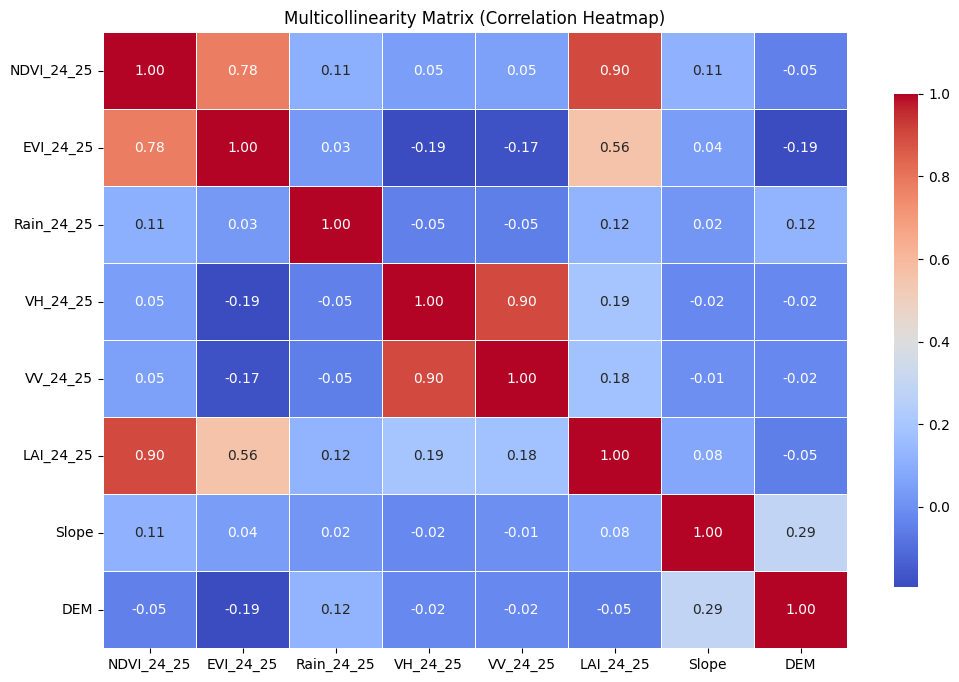

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the correlation matrix for all features in the DataFrame
corr_matrix = gdf_rasters.drop(columns=['geometry', 'H']).corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Multicollinearity Matrix (Correlation Heatmap)")
plt.show()


In [ ]:
gdf_final=gdf_rasters
gdf_final.tail(3)

,H,geometry,NDVI_24_25,EVI_24_25,Rain_24_25,VH_24_25,VV_24_25,LAI_24_25,Slope,DEM
42711,41.614132,POINT (35.18531 1.26155),0.704509,0.401034,640.833313,-15.154576,-7.725158,3.534834,31.995079,2161
42712,41.636768,POINT (35.18422 1.25878),0.665533,0.329635,549.416687,-14.836319,-4.766653,3.386149,24.044718,2314
42713,42.840267,POINT (35.18931 1.26207),0.733166,0.467589,460.666656,-21.373411,-14.416782,3.968927,34.784702,2215


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Convert GeoDataFrame to DataFrame (drop geometry)
df = gdf_final.drop(columns=["geometry"])

# Define input features (X) and target variable (y)
X = df[["NDVI_24_25", "EVI_24_25", "LAI_24_25", "Rain_24_25",  "Slope","DEM"]]
y = df["H"]

# Handle missing values (if any)
X = X.fillna(X.mean())

# Split data into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R² Score: {r2}")

# Save the trained model (optional)
import joblib
joblib.dump(model, "/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_2.pkl")
print("Model saved!")


/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Mean Absolute Error: 3.5028427254416297
R² Score: 0.7267793649423833
Model saved!


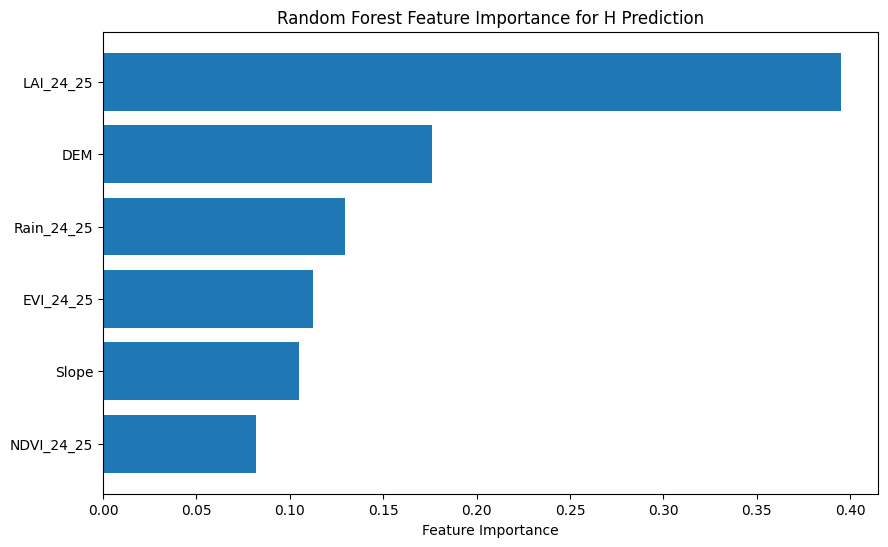

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
importances = model.feature_importances_
features = X.columns

# Sort by importance
sorted_idx = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [features[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance for H Prediction")
plt.show()


In [ ]:
import pandas as pd

# Assuming you already have:
# - `importances` from model.feature_importances_
# - `features` from X.columns

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort by importance (descending)
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Display
print(importance_df)


      Feature  Importance
0   LAI_24_25    0.395145
1         DEM    0.176017
2  Rain_24_25    0.129356
3   EVI_24_25    0.112598
4       Slope    0.104936
5  NDVI_24_25    0.081948


In [ ]:
import rasterio
import numpy as np
import joblib
from rasterio.enums import Resampling

# Load the trained model
model = joblib.load('/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_1.pkl')

# Define raster paths
raster_paths = {
    "NDVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2024_2025_resampled.tif",
    "EVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/EVI_2024_2025_resampled.tif",

    "Rain_24_25": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2024_2025_resampled.tif",
    # "VH_24_25": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2024_2025_resampled.tif",
    "LAI_24_25": "/content/drive/MyDrive/Kamatira Model Data/LAI_2024_2025.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}


# Use NDVI as the reference raster
with rasterio.open(raster_paths["NDVI_24_25"]) as ref:
    ref_meta = ref.meta.copy()  # Save metadata
    ref_height, ref_width = ref.height, ref.width
    ref_transform = ref.transform  # Get reference transform

# Function to resample raster
def resample_raster(src_path, ref_height, ref_width, ref_transform):
    with rasterio.open(src_path) as src:
        data = src.read(1, out_shape=(ref_height, ref_width), resampling=Resampling.bilinear)
        return data

# Read and resample rasters
bands = []
for key, path in raster_paths.items():
    bands.append(resample_raster(path, ref_height, ref_width, ref_transform))

# Convert to NumPy array and reshape
stacked_array = np.stack(bands, axis=0)  # Shape: (bands, height, width)
stacked_array_reshaped = stacked_array.reshape(len(raster_paths), -1).T  # Shape: (pixels, bands)

# Predict H values using the trained model
H_predictions = model.predict(stacked_array_reshaped)

# Reshape predictions back to raster format
H_raster = H_predictions.reshape(ref_height, ref_width)

# Save the predicted raster
ref_meta.update(dtype=rasterio.float32, count=1)

output_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_2025.tif"
with rasterio.open(output_path, "w", **ref_meta) as dst:
    dst.write(H_raster.astype(rasterio.float32), 1)

print(f"Prediction completed! Raster saved at: {output_path}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Prediction completed! Raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_2025.tif


Extracted raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_Masked.tif


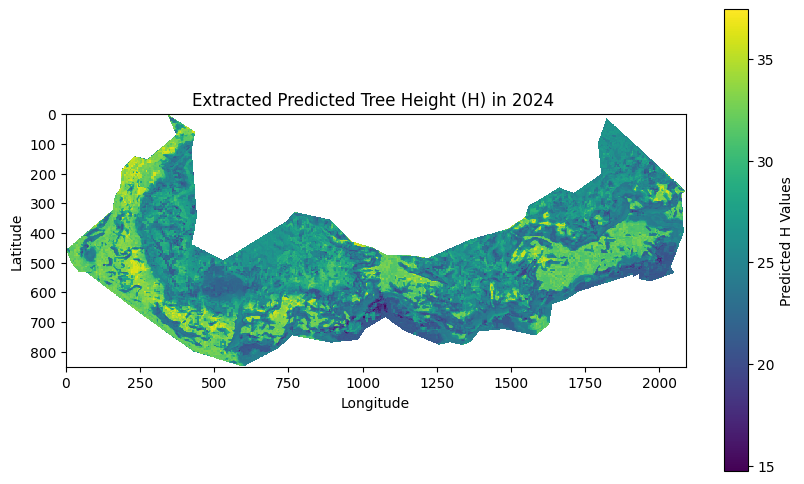

In [ ]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping

# Paths to files
raster_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_2025.tif"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
output_extracted_raster = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_Masked.tif"

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)

# Open the raster and mask it using the geojson file
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
    out_meta = src.meta.copy()
    nodata_value = src.nodata  # Store NoData value

# Update metadata after cropping
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Save the masked raster
with rasterio.open(output_extracted_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("Extracted raster saved at:", output_extracted_raster)

# --- VISUALIZATION ---
# Mask NoData values
masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])

# Create an alpha transparency mask
alpha_mask = np.where(out_image[0] == nodata_value, 0, 1)

# Plot the masked raster
plt.figure(figsize=(10, 6))
plt.imshow(masked_data, cmap="viridis", interpolation="nearest", alpha=alpha_mask)
plt.colorbar(label="Predicted H Values")
plt.title("Extracted Predicted Tree Height (H) in 2024 ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


Try XGBoosT Model

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# Drop geometry column and define features & target
df = gdf_final.drop(columns=["geometry"])  # Remove geometry
X = df[["NDVI_24_25", "EVI_24_25", "VV_24_25", "VH_24_25","LAI_24_25", "Rain_24_25",  "Slope","DEM"]]
y = df["H"]

# Handle missing values (if any)
X = X.fillna(X.mean())

# Split data into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and train the XGBoost model
model = xgb.XGBRegressor(
    n_estimators=1000,   # Number of trees
    learning_rate=0.05,  # Step size
    max_depth=6,         # Tree depth
    subsample=0.8,       # Sample ratio
    colsample_bytree=0.8, # Feature ratio
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R² Score: {r2}")

# Save the trained model
model_path = "/content/drive/MyDrive/Kamatira Model Data/Models/XGBoost_H_Model_1.pkl"
joblib.dump(model, model_path)
print(f" Model saved as {model_path}!")


/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Mean Absolute Error: 4.244275016772809
R² Score: 0.6834141065094201
 Model saved as /content/drive/MyDrive/Kamatira Model Data/Models/XGBoost_H_Model_1.pkl!


Try SVM Model

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
from sklearn.preprocessing import StandardScaler

# Drop geometry column and define features & target
df = gdf_final.drop(columns=["geometry"])  # Remove geometry
X = df[["NDVI_24_25", "EVI_24_25", "LAI_24_25", "Rain_24_25", "Slope", "DEM"]]
y = df["H"]

# Handle missing values (if any)
X = X.fillna(X.mean())

# Important: Scale features for SVM (very sensitive to feature scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define and train the SVM model
svm_model = SVR(kernel='rbf', C=100, epsilon=0.1)  # RBF kernel for non-linear relationships
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Model evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (SVM): {mae:.4f}")
print(f"R² Score (SVM): {r2:.4f}")

# Save the trained model and scaler
model_path = "/content/drive/MyDrive/Kamatira Model Data/Models/SVM_H_Model_2.pkl"
scaler_path = "/content/drive/MyDrive/Kamatira Model Data/Models/SVM_H_Scaler_1.pkl"
joblib.dump(svm_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"SVM Model saved at {model_path}!")
print(f"Scaler saved at {scaler_path}!")


/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Mean Absolute Error (SVM): 5.4287
R² Score (SVM): 0.4492
SVM Model saved at /content/drive/MyDrive/Kamatira Model Data/Models/SVM_H_Model_2.pkl!
Scaler saved at /content/drive/MyDrive/Kamatira Model Data/Models/SVM_H_Scaler_1.pkl!


In [ ]:
import pandas as pd

# Manually entered model evaluation results
data = [
    {
        "Model": "RandomForest_H_Model_1",
        "Backscatter": "With VV & VH",
        "MAE": 3.6280,
        "R²": 0.7276
    },
    {
        "Model": "XGBoost_H_Model_1",
        "Backscatter": "With VV & VH",
        "MAE": 4.2443,
        "R²": 0.6834
    },
    {
        "Model": "SVM_H_Model_1",
        "Backscatter": "With VV & VH",
        "MAE": 5.1244,
        "R²": 0.4924
    },
    {
        "Model": "RandomForest_H_Model_2",
        "Backscatter": "Without VV & VH",
        "MAE": 3.5028,
        "R²": 0.7268
    },
    {
        "Model": "XGBoost_H_Model_2",
        "Backscatter": "Without VV & VH",
        "MAE": 4.2878,
        "R²": 0.6793
    },
    {
        "Model": "SVM_H_Model_2",
        "Backscatter": "Without VV & VH",
        "MAE": 5.4287,
        "R²": 0.4492
    }
]

# Create DataFrame
results_df = pd.DataFrame(data)

# Display
print(results_df)


                    Model      Backscatter     MAE      R²
0  RandomForest_H_Model_1     With VV & VH  3.6280  0.7276
1       XGBoost_H_Model_1     With VV & VH  4.2443  0.6834
2           SVM_H_Model_1     With VV & VH  5.1244  0.4924
3  RandomForest_H_Model_2  Without VV & VH  3.5028  0.7268
4       XGBoost_H_Model_2  Without VV & VH  4.2878  0.6793
5           SVM_H_Model_2  Without VV & VH  5.4287  0.4492


In [ ]:
results_df.head(10)

,Model,Backscatter,MAE,R²
0,RandomForest_H_Model_1,With VV & VH,3.6280,0.7276
1,XGBoost_H_Model_1,With VV & VH,4.2443,0.6834
2,SVM_H_Model_1,With VV & VH,5.1244,0.4924
3,RandomForest_H_Model_2,Without VV & VH,3.5028,0.7268
4,XGBoost_H_Model_2,Without VV & VH,4.2878,0.6793
5,SVM_H_Model_2,Without VV & VH,5.4287,0.4492


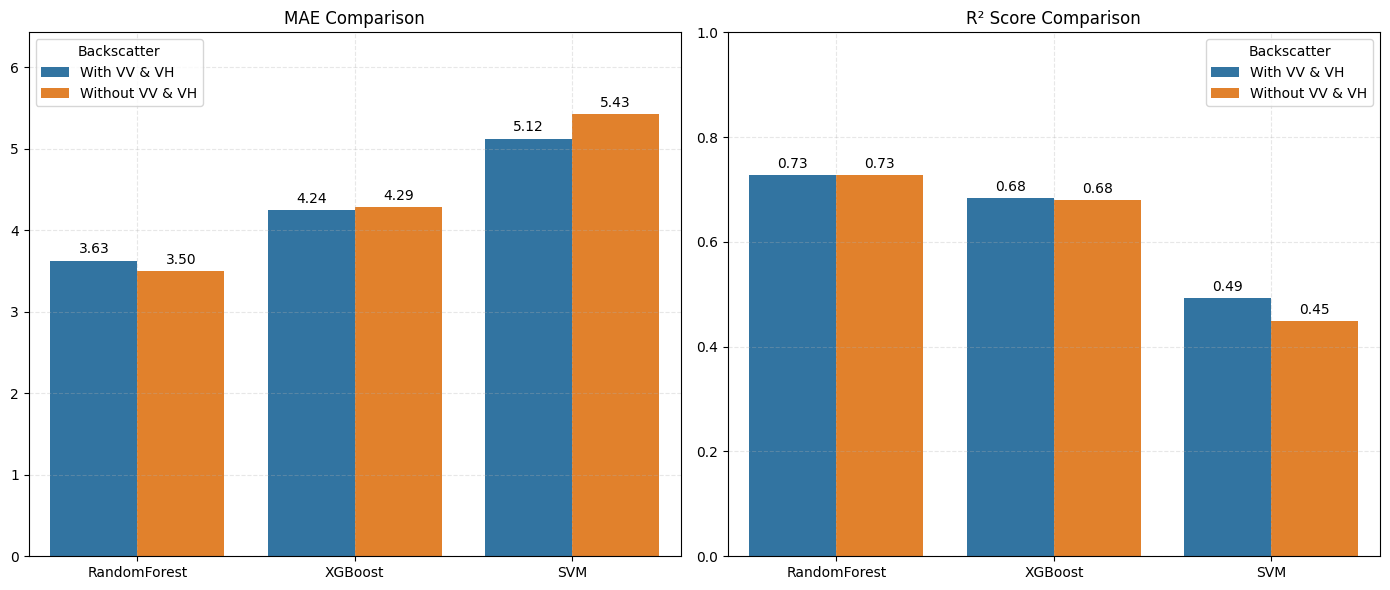

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data
data = {
    "Model": [
        "RandomForest", "XGBoost", "SVM",
        "RandomForest", "XGBoost", "SVM"
    ],
    "Backscatter": [
        "With VV & VH", "With VV & VH", "With VV & VH",
        "Without VV & VH", "Without VV & VH", "Without VV & VH"
    ],
    "MAE": [3.6280, 4.2443, 5.1244, 3.5028, 4.2878, 5.4287],
    "R²": [0.7276, 0.6834, 0.4924, 0.7268, 0.6793, 0.4492]
}

df = pd.DataFrame(data)

# Plotting grouped bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MAE plot
mae_plot = sns.barplot(data=df, x="Model", y="MAE", hue="Backscatter", ax=axes[0])
axes[0].set_title("MAE Comparison")
axes[0].set_ylim(0, max(df["MAE"]) + 1)

# R² plot
r2_plot = sns.barplot(data=df, x="Model", y="R²", hue="Backscatter", ax=axes[1])
axes[1].set_title("R² Score Comparison")
axes[1].set_ylim(0, 1)

# Annotate values on bars
def annotate_bars(ax, metric):
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{v.get_height():.2f}" for v in container], padding=3)

annotate_bars(mae_plot, "MAE")
annotate_bars(r2_plot, "R²")

# Tidy up
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.legend(title="Backscatter")
    ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import joblib
import pandas as pd
import os

model_info = [
    {
        "name": "RandomForest_H_Model_1",
        "path": "/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_1.pkl",
    },
    {
        "name": "RandomForest_H_Model_2",
        "path": "/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_2.pkl",
    },
    {
        "name": "XGBoost_H_Model_1",
        "path": "/content/drive/MyDrive/Kamatira Model Data/Models/XGBoost_H_Model_1.pkl",
    },
    {
        "name": "XGBoost_H_Model_2",
        "path": "/content/drive/MyDrive/Kamatira Model Data/Models/XGBoost_H_Model_2.pkl",
    },
        {
        "name": "SVM_H_Model_1.pkl",
        "path": "/content/drive/MyDrive/Kamatira Model Data/Models/SVM_H_Model_1.pkl",
    },
    {
        "name": "SVM_H_Model_2.pkl",
        "path": "/content/drive/MyDrive/Kamatira Model Data/Models/SVM_H_Model_2.pkl",
    }
]

importance_df_list = []

for info in model_info:
    model = joblib.load(info["path"])

    try:
        # Try to get feature names from model
        features = model.feature_names_in_
    except AttributeError:
        # If not available, warn and skip
        print(f"Feature names not found in {info['name']}, skipping.")
        continue

    importances = model.feature_importances_

    if len(importances) != len(features):
        print(f"Mismatch in lengths for {info['name']}: {len(importances)} importances vs {len(features)} features")
        continue

    temp_df = pd.DataFrame({
        "Feature": features,
        "Importance": importances,
        "Model": info["name"]
    })
    importance_df_list.append(temp_df)

# Combine all into one DataFrame
feature_importance_df = pd.concat(importance_df_list)
feature_importance_df.sort_values(by="Importance", ascending=False, inplace=True)

# Display
print(feature_importance_df.head(15))


Feature names not found in SVM_H_Model_1.pkl, skipping.
Feature names not found in SVM_H_Model_2.pkl, skipping.
      Feature  Importance                   Model
2   LAI_24_25    0.432906       XGBoost_H_Model_2
2   LAI_24_25    0.395145  RandomForest_H_Model_2
2   LAI_24_25    0.395145  RandomForest_H_Model_1
4   LAI_24_25    0.367222       XGBoost_H_Model_1
5         DEM    0.176017  RandomForest_H_Model_1
5         DEM    0.176017  RandomForest_H_Model_2
5         DEM    0.151309       XGBoost_H_Model_2
3  Rain_24_25    0.129356  RandomForest_H_Model_1
3  Rain_24_25    0.129356  RandomForest_H_Model_2
7         DEM    0.129168       XGBoost_H_Model_1
3  Rain_24_25    0.122890       XGBoost_H_Model_2
1   EVI_24_25    0.112598  RandomForest_H_Model_1
1   EVI_24_25    0.112598  RandomForest_H_Model_2
0  NDVI_24_25    0.111908       XGBoost_H_Model_1
4       Slope    0.104936  RandomForest_H_Model_1


In [ ]:
import joblib
import pandas as pd

# Feature sets
features_model1 = ["NDVI_24_25", "EVI_24_25", "VV_24_25", "VH_24_25", "LAI_24_25", "Rain_24_25", "Slope", "DEM"]
features_model2 = ["NDVI_24_25", "EVI_24_25", "LAI_24_25", "Rain_24_25", "Slope", "DEM"]

# Model info
model_info = [
    {"name": "RandomForest_H_Model_1", "path": "/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_1.pkl"},
    {"name": "RandomForest_H_Model_2", "path": "/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_2.pkl"},
    {"name": "XGBoost_H_Model_1", "path": "/content/drive/MyDrive/Kamatira Model Data/Models/XGBoost_H_Model_1.pkl"},
    {"name": "XGBoost_H_Model_2", "path": "/content/drive/MyDrive/Kamatira Model Data/Models/XGBoost_H_Model_2.pkl"},
    {"name": "SVM_H_Model_1.pkl", "path": "/content/drive/MyDrive/Kamatira Model Data/Models/SVM_H_Model_1.pkl"},
    {"name": "SVM_H_Model_2.pkl", "path": "/content/drive/MyDrive/Kamatira Model Data/Models/SVM_H_Model_2.pkl"}
]

# Output list
results = []

for info in model_info:
    model_name = info['name']
    if model_name.startswith("SVM"):
        continue  # Skip SVMs

    try:
        model = joblib.load(info["path"])

        # Select appropriate feature list
        if "Model_1" in model_name:
            features = features_model1
        elif "Model_2" in model_name:
            features = features_model2
        else:
            features = []  # Fallback

        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
            for i, score in enumerate(importances):
                feature = features[i] if i < len(features) else f"feature_{i}"
                results.append({
                    "model": model_name,
                    "feature": feature,
                    "importance": score
                })

        elif hasattr(model, "get_booster"):
            booster = model.get_booster()
            importances = booster.get_score(importance_type='weight')
            for feat, score in importances.items():
                idx = int(feat.strip("f"))
                feature = features[idx] if idx < len(features) else feat
                results.append({
                    "model": model_name,
                    "feature": feature,
                    "importance": score
                })

        else:
            print(f"[INFO] No feature importance in {model_name}")

    except Exception as e:
        print(f"Error loading {model_name}: {e}")

# Convert to DataFrame
importance_df = pd.DataFrame(results)
importance_df = importance_df.sort_values(by=["model", "importance"], ascending=[True, False])

# Display summary
print(importance_df)


                     model     feature  importance
2   RandomForest_H_Model_1    VV_24_25    0.395145
5   RandomForest_H_Model_1  Rain_24_25    0.176017
3   RandomForest_H_Model_1    VH_24_25    0.129356
1   RandomForest_H_Model_1   EVI_24_25    0.112598
4   RandomForest_H_Model_1   LAI_24_25    0.104936
0   RandomForest_H_Model_1  NDVI_24_25    0.081948
8   RandomForest_H_Model_2   LAI_24_25    0.395145
11  RandomForest_H_Model_2         DEM    0.176017
9   RandomForest_H_Model_2  Rain_24_25    0.129356
7   RandomForest_H_Model_2   EVI_24_25    0.112598
10  RandomForest_H_Model_2       Slope    0.104936
6   RandomForest_H_Model_2  NDVI_24_25    0.081948
16       XGBoost_H_Model_1   LAI_24_25    0.367222
19       XGBoost_H_Model_1         DEM    0.129168
12       XGBoost_H_Model_1  NDVI_24_25    0.111908
13       XGBoost_H_Model_1   EVI_24_25    0.101880
17       XGBoost_H_Model_1  Rain_24_25    0.096734
18       XGBoost_H_Model_1       Slope    0.075642
14       XGBoost_H_Model_1    V

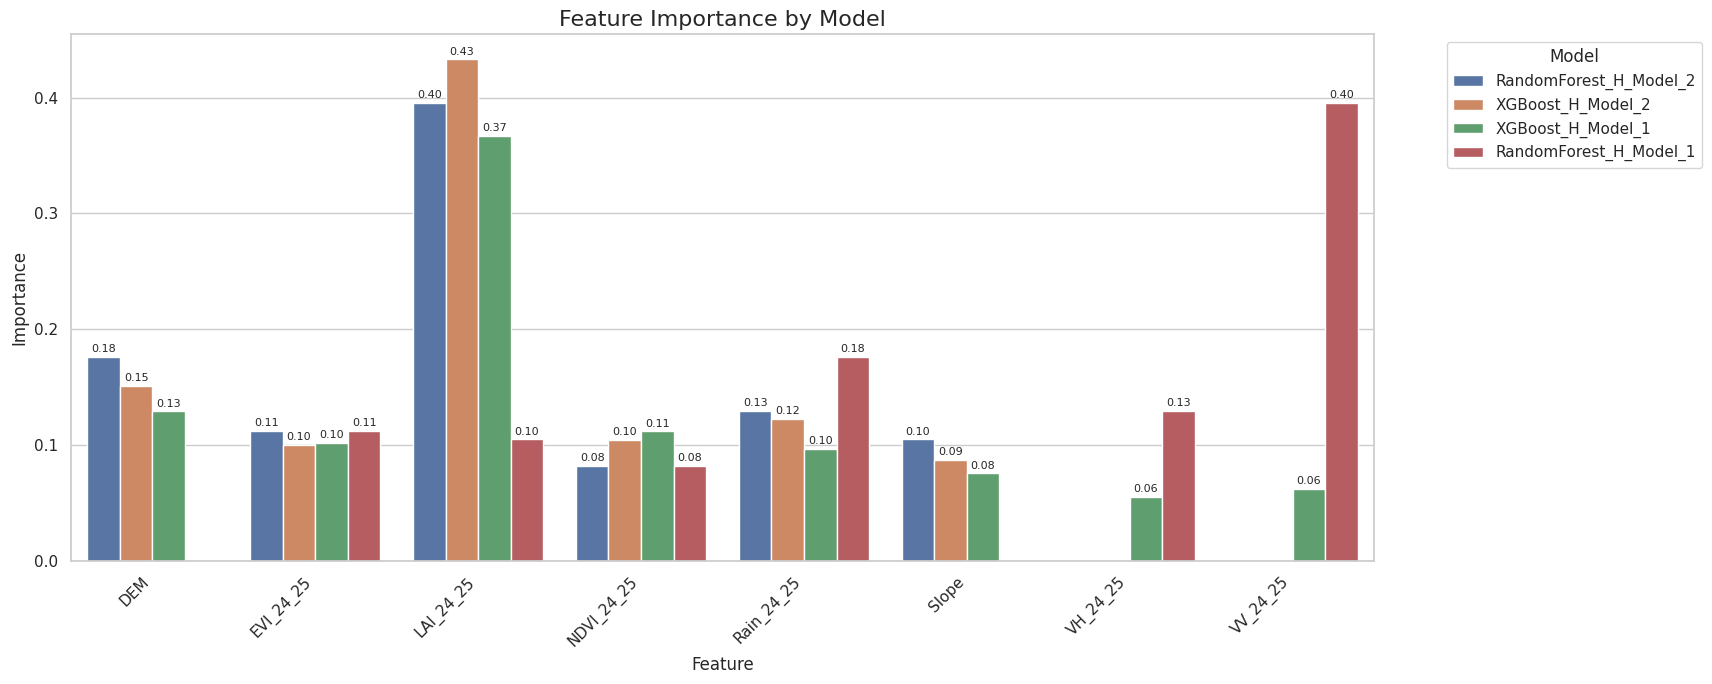

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure column names are title-cased to match plotting code
importance_df.rename(columns={
    "model": "Model",
    "feature": "Feature",
    "importance": "Importance"
}, inplace=True)

# Set Seaborn style
sns.set(style="whitegrid")

# Sort for cleaner plot layout
sorted_df = importance_df.sort_values(by=["Feature", "Importance"], ascending=[True, False])

# Initialize the plot
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=sorted_df,
    x="Feature",
    y="Importance",
    hue="Model"
)

# Annotate bars with importance values
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", fontsize=8, padding=2)

# Customize plot
plt.title("Feature Importance by Model", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


Backscatter The Heights

2020

In [ ]:
import rasterio
import numpy as np
import joblib
from rasterio.enums import Resampling

# Load the trained model
model = joblib.load('/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_1.pkl')

# Define raster paths for 2019-2020
raster_paths = {
    "NDVI_19_20": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2019_2020_resampled.tif",
    "EVI_19_20": "/content/drive/MyDrive/Kamatira Model Data/EVI_2019_2020_resampled.tif",
    # Include VH if you have it, otherwise comment it out
    # "VH_19_20": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2019_2020_resampled.tif",
    "Rain_19_20": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2019_2020_resampled.tif",
    "LAI_19_20": "/content/drive/MyDrive/Kamatira Model Data/LAI_2019_2020.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}

# Use NDVI as the reference raster
with rasterio.open(raster_paths["NDVI_19_20"]) as ref:
    ref_meta = ref.meta.copy()  # Save metadata
    ref_height, ref_width = ref.height, ref.width
    ref_transform = ref.transform  # Get reference transform

# Function to resample raster
def resample_raster(src_path, ref_height, ref_width, ref_transform):
    with rasterio.open(src_path) as src:
        data = src.read(1, out_shape=(ref_height, ref_width), resampling=Resampling.bilinear)
        return data

# Read and resample rasters
bands = []
for key, path in raster_paths.items():
    bands.append(resample_raster(path, ref_height, ref_width, ref_transform))

# Convert to NumPy array and reshape
stacked_array = np.stack(bands, axis=0)  # Shape: (bands, height, width)
stacked_array_reshaped = stacked_array.reshape(len(raster_paths), -1).T  # Shape: (pixels, bands)

# Predict H values using the trained model
H_predictions = model.predict(stacked_array_reshaped)

# Reshape predictions back to raster format
H_raster = H_predictions.reshape(ref_height, ref_width)

# Save the predicted raster
ref_meta.update(dtype=rasterio.float32, count=1)

output_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2019_2020.tif"
with rasterio.open(output_path, "w", **ref_meta) as dst:
    dst.write(H_raster.astype(rasterio.float32), 1)

print(f"Prediction completed! Raster saved at: {output_path}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Prediction completed! Raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2019_2020.tif


Visualize 2020

Extracted raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2020_Masked.tif


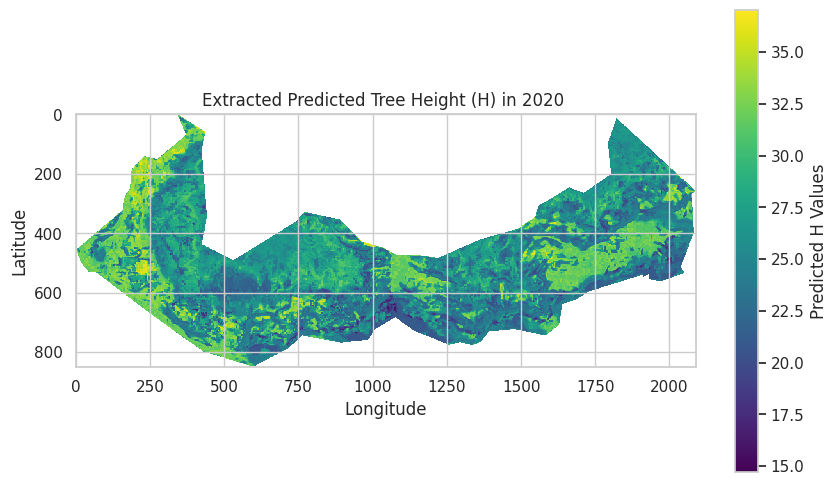

In [ ]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping

# Paths to files
raster_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2019_2020.tif"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
output_extracted_raster = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2020_Masked.tif"

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)

# Open the raster and mask it using the geojson file
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
    out_meta = src.meta.copy()
    nodata_value = src.nodata  # Store NoData value

# Update metadata after cropping
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Save the masked raster
with rasterio.open(output_extracted_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("Extracted raster saved at:", output_extracted_raster)

# --- VISUALIZATION ---
# Mask NoData values
masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])

# Create an alpha transparency mask
alpha_mask = np.where(out_image[0] == nodata_value, 0, 1)

# Plot the masked raster
plt.figure(figsize=(10, 6))
plt.imshow(masked_data, cmap="viridis", interpolation="nearest", alpha=alpha_mask)
plt.colorbar(label="Predicted H Values")
plt.title("Extracted Predicted Tree Height (H) in 2020 ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


Change Detection

Height change raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Change_2024_2019.tif


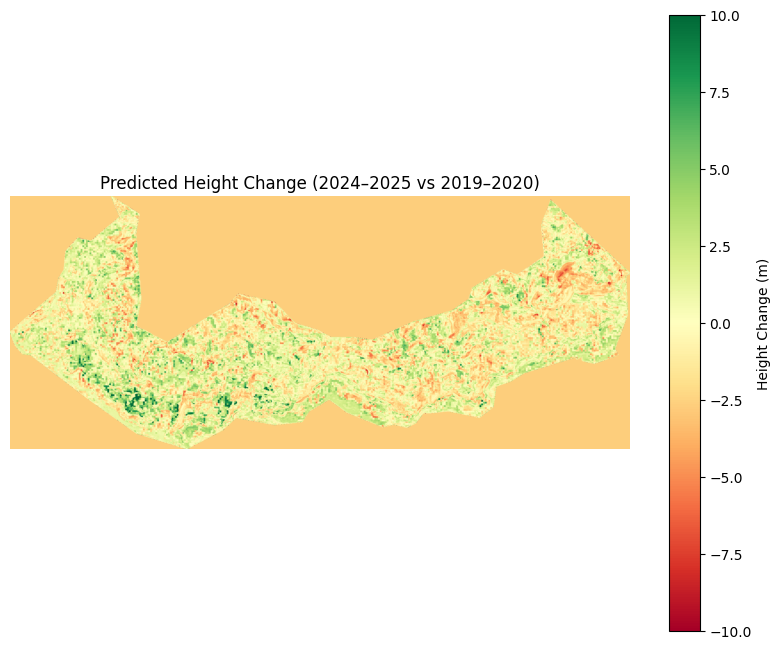

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Load the predicted height rasters
path_2019 = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2019_2020.tif"
path_2024 = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_2025.tif"

with rasterio.open(path_2019) as src_2019, rasterio.open(path_2024) as src_2024:
    H_2019 = src_2019.read(1)
    H_2024 = src_2024.read(1)
    meta = src_2019.meta.copy()  # Keep metadata for saving

# Calculate height change
height_change = H_2024 - H_2019

# Save height change raster
meta.update(dtype=rasterio.float32, count=1)
change_output_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Change_2024_2019.tif"

with rasterio.open(change_output_path, "w", **meta) as dst:
    dst.write(height_change.astype(rasterio.float32), 1)

print(f"Height change raster saved at: {change_output_path}")

# Visualize
plt.figure(figsize=(10, 8))
cmap = plt.cm.RdYlGn  # Green for increase, Red for decrease
vmin, vmax = -10, 10  # Set sensible limits, adjust as needed
plt.imshow(height_change, cmap=cmap, vmin=vmin, vmax=vmax)
plt.colorbar(label="Height Change (m)")
plt.title("Predicted Height Change (2024–2025 vs 2019–2020)")
plt.axis('off')
plt.show()


Extracted raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Change_2020_2025_Masked.tif


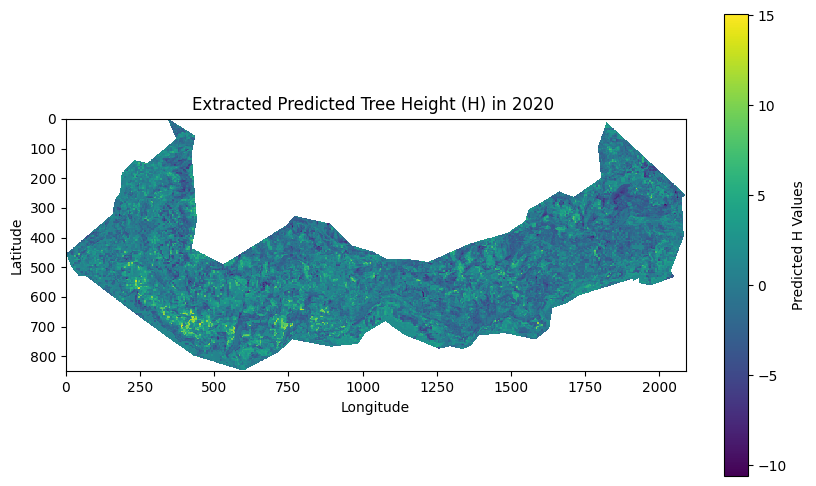

In [ ]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping

# Paths to files
raster_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Change_2024_2019.tif"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
output_extracted_raster = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Change_2020_2025_Masked.tif"

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)

# Open the raster and mask it using the geojson file
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
    out_meta = src.meta.copy()
    nodata_value = src.nodata  # Store NoData value

# Update metadata after cropping
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Save the masked raster
with rasterio.open(output_extracted_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("Extracted raster saved at:", output_extracted_raster)

# --- VISUALIZATION ---
# Mask NoData values
masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])

# Create an alpha transparency mask
alpha_mask = np.where(out_image[0] == nodata_value, 0, 1)

# Plot the masked raster
plt.figure(figsize=(10, 6))
plt.imshow(masked_data, cmap="viridis", interpolation="nearest", alpha=alpha_mask)
plt.colorbar(label="Predicted H Values")
plt.title("Extracted Predicted Tree Height (H) in 2020 ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


Backscatter 2015

In [ ]:
import rasterio
import numpy as np
import joblib
from rasterio.enums import Resampling

# Load the trained model
model = joblib.load('/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_1.pkl')

# Define raster paths for 2019-2020
raster_paths = {
    "NDVI_14_15": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2014_2015_resampled.tif",
    "EVI_14_15": "/content/drive/MyDrive/Kamatira Model Data/EVI_2014_2015_resampled.tif",
    # Include VH if you have it, otherwise comment it out
    # "VH_19_20": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2019_2020_resampled.tif",
    "Rain_14_15": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2014_2015_resampled.tif",
    "LAI_14_15": "/content/drive/MyDrive/Kamatira Model Data/LAI_2014_2015.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}

# Use NDVI as the reference raster
with rasterio.open(raster_paths["NDVI_14_15"]) as ref:
    ref_meta = ref.meta.copy()  # Save metadata
    ref_height, ref_width = ref.height, ref.width
    ref_transform = ref.transform  # Get reference transform

# Function to resample raster
def resample_raster(src_path, ref_height, ref_width, ref_transform):
    with rasterio.open(src_path) as src:
        data = src.read(1, out_shape=(ref_height, ref_width), resampling=Resampling.bilinear)
        return data

# Read and resample rasters
bands = []
for key, path in raster_paths.items():
    bands.append(resample_raster(path, ref_height, ref_width, ref_transform))

# Convert to NumPy array and reshape
stacked_array = np.stack(bands, axis=0)  # Shape: (bands, height, width)
stacked_array_reshaped = stacked_array.reshape(len(raster_paths), -1).T  # Shape: (pixels, bands)

# Predict H values using the trained model
H_predictions = model.predict(stacked_array_reshaped)

# Reshape predictions back to raster format
H_raster = H_predictions.reshape(ref_height, ref_width)

# Save the predicted raster
ref_meta.update(dtype=rasterio.float32, count=1)

output_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2014_2015.tif"
with rasterio.open(output_path, "w", **ref_meta) as dst:
    dst.write(H_raster.astype(rasterio.float32), 1)

print(f"Prediction completed! Raster saved at: {output_path}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Prediction completed! Raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2014_2015.tif


Visualize 2015

Extracted raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2015_Masked.tif


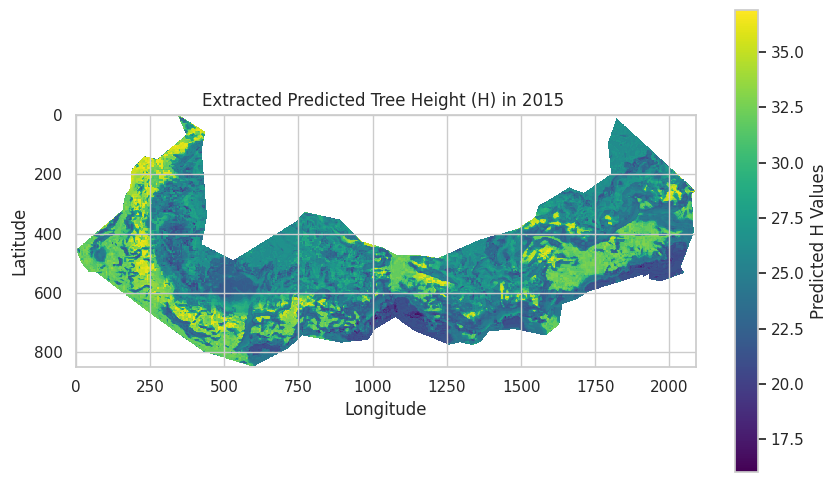

In [ ]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping

# Paths to files
raster_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2014_2015.tif"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
output_extracted_raster = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2015_Masked.tif"

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)

# Open the raster and mask it using the geojson file
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
    out_meta = src.meta.copy()
    nodata_value = src.nodata  # Store NoData value

# Update metadata after cropping
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Save the masked raster
with rasterio.open(output_extracted_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("Extracted raster saved at:", output_extracted_raster)

# --- VISUALIZATION ---
# Mask NoData values
masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])

# Create an alpha transparency mask
alpha_mask = np.where(out_image[0] == nodata_value, 0, 1)

# Plot the masked raster
plt.figure(figsize=(10, 6))
plt.imshow(masked_data, cmap="viridis", interpolation="nearest", alpha=alpha_mask)
plt.colorbar(label="Predicted H Values")
plt.title("Extracted Predicted Tree Height (H) in 2015 ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


Append Summary Stats of 2015-204

In [ ]:
import rasterio
import numpy as np

# List of your raster files
raster_paths = {
    "1990": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_Masked_1990.tif",
    "1995": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_Masked_1995.tif",
    "2000": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_Masked_2000.tif",
    "2005": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_Masked_2005.tif",
    "2010": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_Masked_2010.tif",
    "2015": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2015_Masked.tif",
    "2020": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2020_Masked.tif",
    "2024": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_Masked.tif"
}

# Function to calculate stats
def calculate_stats(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        # Mask no data values
        data = np.ma.masked_equal(data, src.nodata)

        stats = {
            "Mean": data.mean(),
            "Min": data.min(),
            "Max": data.max(),
            "Std Dev": data.std()
        }
        return stats

# Calculate and print stats for each raster
for year, path in raster_paths.items():
    stats = calculate_stats(path)
    print(f"Summary statistics for {year}:")
    for stat_name, value in stats.items():
        print(f"  {stat_name}: {value:.2f}")
    print("-" * 40)


Summary statistics for 1990:
  Mean: 30.20
  Min: 10.15
  Max: 39.91
  Std Dev: 2.99
----------------------------------------
Summary statistics for 1995:
  Mean: 30.31
  Min: 9.98
  Max: 39.55
  Std Dev: 3.06
----------------------------------------
Summary statistics for 2000:
  Mean: 30.10
  Min: 11.37
  Max: 40.15
  Std Dev: 3.17
----------------------------------------
Summary statistics for 2005:
  Mean: 30.64
  Min: 6.22
  Max: 41.18
  Std Dev: 3.56
----------------------------------------
Summary statistics for 2010:
  Mean: 30.18
  Min: 10.15
  Max: 40.33
  Std Dev: 3.13
----------------------------------------
Summary statistics for 2015:
  Mean: 26.79
  Min: 16.03
  Max: 36.89
  Std Dev: 3.85
----------------------------------------
Summary statistics for 2020:
  Mean: 26.71
  Min: 14.73
  Max: 37.05
  Std Dev: 3.71
----------------------------------------
Summary statistics for 2024:
  Mean: 27.62
  Min: 12.57
  Max: 36.31
  Std Dev: 3.61
-----------------------------------

Backscatter for 2010

In [ ]:
import rasterio
import numpy as np
import joblib
from rasterio.enums import Resampling

# Load the trained model
model = joblib.load('/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_1.pkl')

# Define raster paths for 2019-2020
raster_paths = {
    "NDVI_09_10": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2009_2010.tif",
    "EVI_09_10": "/content/drive/MyDrive/Kamatira Model Data/EVI_2009_2010.tif",
    # Include VH if you have it, otherwise comment it out
    # "VH_19_20": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2019_2020_resampled.tif",
    "Rain_09_10": "/content/drive/MyDrive/Kamatira Model Data/Precip_2010.tif",
    "LAI_09_10": "/content/drive/MyDrive/Kamatira Model Data/LAI_2009_2010.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}

# Use NDVI as the reference raster
with rasterio.open(raster_paths["NDVI_09_10"]) as ref:
    ref_meta = ref.meta.copy()  # Save metadata
    ref_height, ref_width = ref.height, ref.width
    ref_transform = ref.transform  # Get reference transform

# Function to resample raster
def resample_raster(src_path, ref_height, ref_width, ref_transform):
    with rasterio.open(src_path) as src:
        data = src.read(1, out_shape=(ref_height, ref_width), resampling=Resampling.bilinear)
        return data

# Read and resample rasters
bands = []
for key, path in raster_paths.items():
    bands.append(resample_raster(path, ref_height, ref_width, ref_transform))

# Convert to NumPy array and reshape
stacked_array = np.stack(bands, axis=0)  # Shape: (bands, height, width)
stacked_array_reshaped = stacked_array.reshape(len(raster_paths), -1).T  # Shape: (pixels, bands)

# Predict H values using the trained model
H_predictions = model.predict(stacked_array_reshaped)

# Reshape predictions back to raster format
H_raster = H_predictions.reshape(ref_height, ref_width)

# Save the predicted raster
ref_meta.update(dtype=rasterio.float32, count=1)

output_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2009_2010.tif"
with rasterio.open(output_path, "w", **ref_meta) as dst:
    dst.write(H_raster.astype(rasterio.float32), 1)

print(f"Prediction completed! Raster saved at: {output_path}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Prediction completed! Raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2009_2010.tif


Extracted raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2010_Masked.tif


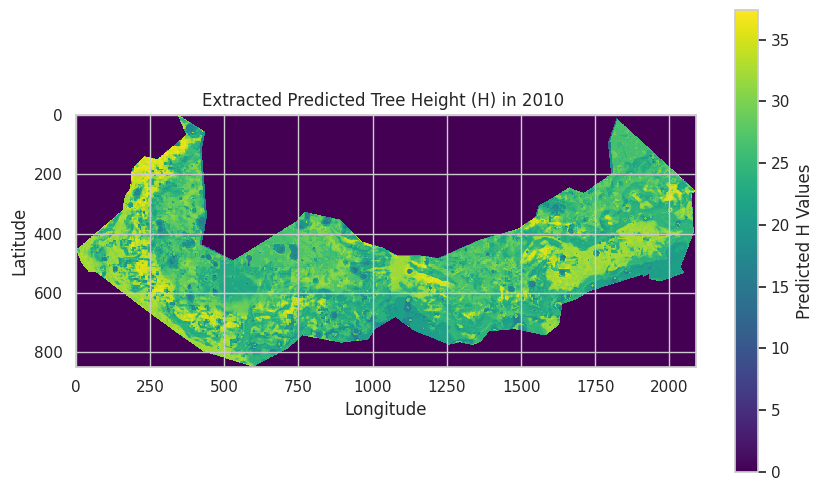

In [ ]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping

# Paths to files
raster_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2009_2010.tif"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
output_extracted_raster = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2010_Masked.tif"

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)

# Open the raster and mask it using the geojson file
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
    out_meta = src.meta.copy()
    nodata_value = src.nodata  # Store NoData value

# Update metadata after cropping
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Save the masked raster
with rasterio.open(output_extracted_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("Extracted raster saved at:", output_extracted_raster)

# --- VISUALIZATION ---
# Mask NoData values
masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])

# Create an alpha transparency mask
alpha_mask = np.where(out_image[0] == nodata_value, 0, 1)

# Plot the masked raster
plt.figure(figsize=(10, 6))
plt.imshow(masked_data, cmap="viridis", interpolation="nearest", alpha=alpha_mask)
plt.colorbar(label="Predicted H Values")
plt.title("Extracted Predicted Tree Height (H) in 2010 ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


Backscatter for 2005

In [ ]:
import rasterio
import numpy as np
import joblib
from rasterio.enums import Resampling

# Load the trained model
model = joblib.load('/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_1.pkl')

# Define raster paths for 2019-2020
raster_paths = {
    "NDVI_04_05": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2004_2005.tif",
    "EVI_04_05": "/content/drive/MyDrive/Kamatira Model Data/EVI_2004_2005.tif",
    # Include VH if you have it, otherwise comment it out
    # "VH_19_20": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2019_2020_resampled.tif",
    "Rain_04_05": "/content/drive/MyDrive/Kamatira Model Data/Precip_2005.tif",
    "LAI_04_05": "/content/drive/MyDrive/Kamatira Model Data/LAI_2004_2005.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}

# Use NDVI as the reference raster
with rasterio.open(raster_paths["NDVI_04_05"]) as ref:
    ref_meta = ref.meta.copy()  # Save metadata
    ref_height, ref_width = ref.height, ref.width
    ref_transform = ref.transform  # Get reference transform

# Function to resample raster
def resample_raster(src_path, ref_height, ref_width, ref_transform):
    with rasterio.open(src_path) as src:
        data = src.read(1, out_shape=(ref_height, ref_width), resampling=Resampling.bilinear)
        return data

# Read and resample rasters
bands = []
for key, path in raster_paths.items():
    bands.append(resample_raster(path, ref_height, ref_width, ref_transform))

# Convert to NumPy array and reshape
stacked_array = np.stack(bands, axis=0)  # Shape: (bands, height, width)
stacked_array_reshaped = stacked_array.reshape(len(raster_paths), -1).T  # Shape: (pixels, bands)

# Predict H values using the trained model
H_predictions = model.predict(stacked_array_reshaped)

# Reshape predictions back to raster format
H_raster = H_predictions.reshape(ref_height, ref_width)

# Save the predicted raster
ref_meta.update(dtype=rasterio.float32, count=1)

output_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2004_2005.tif"
with rasterio.open(output_path, "w", **ref_meta) as dst:
    dst.write(H_raster.astype(rasterio.float32), 1)

print(f"Prediction completed! Raster saved at: {output_path}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Prediction completed! Raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2004_2005.tif


Extracted raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2005_Masked.tif


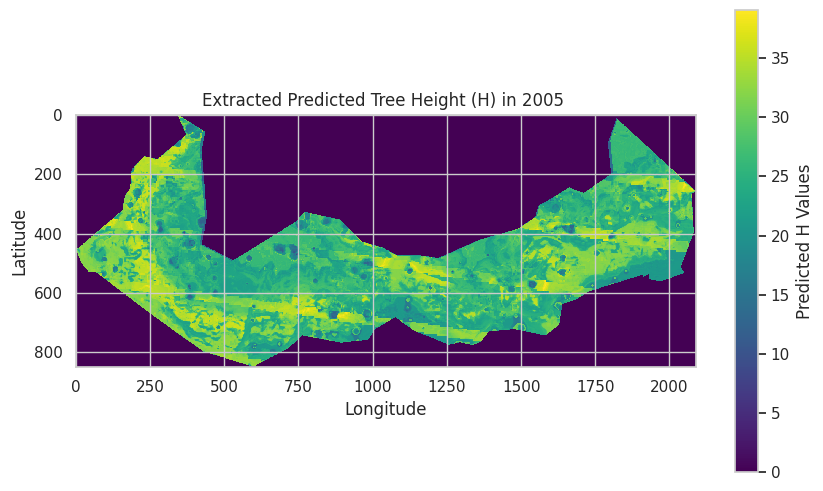

In [ ]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping

# Paths to files
raster_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2004_2005.tif"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
output_extracted_raster = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2005_Masked.tif"

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)

# Open the raster and mask it using the geojson file
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
    out_meta = src.meta.copy()
    nodata_value = src.nodata  # Store NoData value

# Update metadata after cropping
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Save the masked raster
with rasterio.open(output_extracted_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("Extracted raster saved at:", output_extracted_raster)

# --- VISUALIZATION ---
# Mask NoData values
masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])

# Create an alpha transparency mask
alpha_mask = np.where(out_image[0] == nodata_value, 0, 1)

# Plot the masked raster
plt.figure(figsize=(10, 6))
plt.imshow(masked_data, cmap="viridis", interpolation="nearest", alpha=alpha_mask)
plt.colorbar(label="Predicted H Values")
plt.title("Extracted Predicted Tree Height (H) in 2005 ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


Backscatter for 2000

In [ ]:
import rasterio
import numpy as np
import joblib
from rasterio.enums import Resampling

# Load the trained model
model = joblib.load('/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_1.pkl')

# Define raster paths for 1989-2000
raster_paths = {
    "NDVI_99_00": "/content/drive/MyDrive/Kamatira Model Data/NDVI_1999_2000.tif",
    "EVI_99_00": "/content/drive/MyDrive/Kamatira Model Data/EVI_1999_2000.tif",
    # Include VH if you have it, otherwise comment it out
    # "VH_19_20": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2019_2020_resampled.tif",
    "Rain_99_00": "/content/drive/MyDrive/Kamatira Model Data/Precip_2000.tif",
    "LAI_99_00": "/content/drive/MyDrive/Kamatira Model Data/LAI_1999_2000.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}

# Use NDVI as the reference raster
with rasterio.open(raster_paths["NDVI_99_00"]) as ref:
    ref_meta = ref.meta.copy()  # Save metadata
    ref_height, ref_width = ref.height, ref.width
    ref_transform = ref.transform  # Get reference transform

# Function to resample raster
def resample_raster(src_path, ref_height, ref_width, ref_transform):
    with rasterio.open(src_path) as src:
        data = src.read(1, out_shape=(ref_height, ref_width), resampling=Resampling.bilinear)
        return data

# Read and resample rasters
bands = []
for key, path in raster_paths.items():
    bands.append(resample_raster(path, ref_height, ref_width, ref_transform))

# Convert to NumPy array and reshape
stacked_array = np.stack(bands, axis=0)  # Shape: (bands, height, width)
stacked_array_reshaped = stacked_array.reshape(len(raster_paths), -1).T  # Shape: (pixels, bands)

# Predict H values using the trained model
H_predictions = model.predict(stacked_array_reshaped)

# Reshape predictions back to raster format
H_raster = H_predictions.reshape(ref_height, ref_width)

# Save the predicted raster
ref_meta.update(dtype=rasterio.float32, count=1)

output_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1999_2000.tif"
with rasterio.open(output_path, "w", **ref_meta) as dst:
    dst.write(H_raster.astype(rasterio.float32), 1)

print(f"Prediction completed! Raster saved at: {output_path}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Prediction completed! Raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1999_2000.tif


Extracted raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2000_Masked.tif


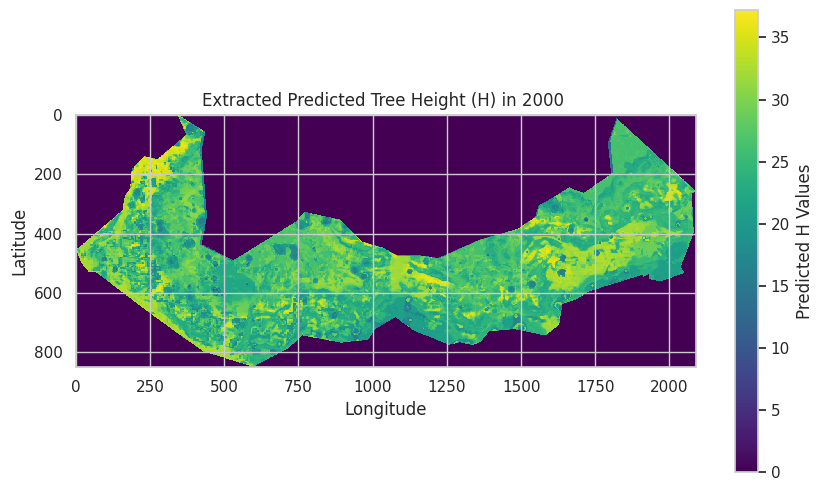

In [ ]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping

# Paths to files
raster_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1999_2000.tif"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
output_extracted_raster = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2000_Masked.tif"

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)

# Open the raster and mask it using the geojson file
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
    out_meta = src.meta.copy()
    nodata_value = src.nodata  # Store NoData value

# Update metadata after cropping
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Save the masked raster
with rasterio.open(output_extracted_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("Extracted raster saved at:", output_extracted_raster)

# --- VISUALIZATION ---
# Mask NoData values
masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])

# Create an alpha transparency mask
alpha_mask = np.where(out_image[0] == nodata_value, 0, 1)

# Plot the masked raster
plt.figure(figsize=(10, 6))
plt.imshow(masked_data, cmap="viridis", interpolation="nearest", alpha=alpha_mask)
plt.colorbar(label="Predicted H Values")
plt.title("Extracted Predicted Tree Height (H) in 2000 ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


Compare CHM derived from NASDEM and SRTM DSM

Backscatter for 1995

In [ ]:
import rasterio
import numpy as np
import joblib
from rasterio.enums import Resampling

# Load the trained model
model = joblib.load('/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_1.pkl')

# Define raster paths for 1989-2000
raster_paths = {
    "NDVI_94_95": "/content/drive/MyDrive/Kamatira Model Data/NDVI_1994_1995.tif",
    "EVI_94_95": "/content/drive/MyDrive/Kamatira Model Data/EVI_1994_1995.tif",
    # Include VH if you have it, otherwise comment it out
    # "VH_19_20": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2019_2020_resampled.tif",
    "Rain_94_95": "/content/drive/MyDrive/Kamatira Model Data/Precip_1995.tif",
    "LAI_94_95": "/content/drive/MyDrive/Kamatira Model Data/LAI_1994_1995.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}

# Use NDVI as the reference raster
with rasterio.open(raster_paths["NDVI_94_95"]) as ref:
    ref_meta = ref.meta.copy()  # Save metadata
    ref_height, ref_width = ref.height, ref.width
    ref_transform = ref.transform  # Get reference transform

# Function to resample raster
def resample_raster(src_path, ref_height, ref_width, ref_transform):
    with rasterio.open(src_path) as src:
        data = src.read(1, out_shape=(ref_height, ref_width), resampling=Resampling.bilinear)
        return data

# Read and resample rasters
bands = []
for key, path in raster_paths.items():
    bands.append(resample_raster(path, ref_height, ref_width, ref_transform))

# Convert to NumPy array and reshape
stacked_array = np.stack(bands, axis=0)  # Shape: (bands, height, width)
stacked_array_reshaped = stacked_array.reshape(len(raster_paths), -1).T  # Shape: (pixels, bands)

# Predict H values using the trained model
H_predictions = model.predict(stacked_array_reshaped)

# Reshape predictions back to raster format
H_raster = H_predictions.reshape(ref_height, ref_width)

# Save the predicted raster
ref_meta.update(dtype=rasterio.float32, count=1)

output_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1994_1995.tif"
with rasterio.open(output_path, "w", **ref_meta) as dst:
    dst.write(H_raster.astype(rasterio.float32), 1)

print(f"Prediction completed! Raster saved at: {output_path}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Prediction completed! Raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1994_1995.tif


Extracted raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1995_Masked.tif


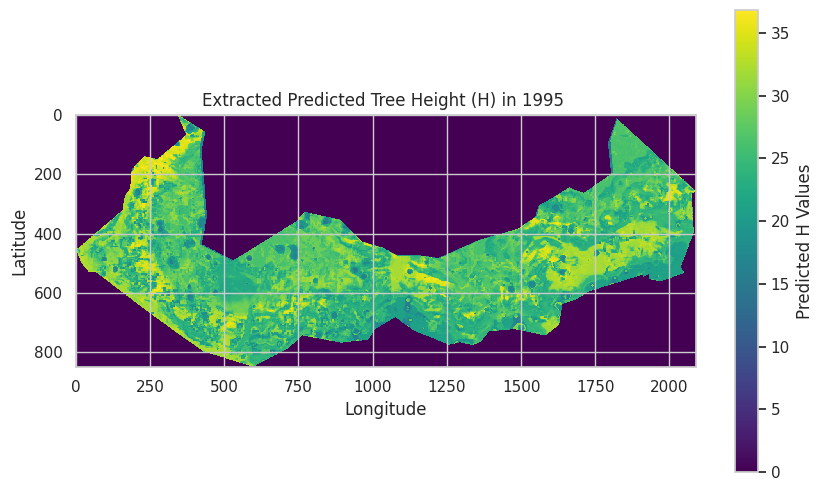

In [ ]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping

# Paths to files
raster_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1994_1995.tif"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
output_extracted_raster = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1995_Masked.tif"

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)

# Open the raster and mask it using the geojson file
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
    out_meta = src.meta.copy()
    nodata_value = src.nodata  # Store NoData value

# Update metadata after cropping
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Save the masked raster
with rasterio.open(output_extracted_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("Extracted raster saved at:", output_extracted_raster)

# --- VISUALIZATION ---
# Mask NoData values
masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])

# Create an alpha transparency mask
alpha_mask = np.where(out_image[0] == nodata_value, 0, 1)

# Plot the masked raster
plt.figure(figsize=(10, 6))
plt.imshow(masked_data, cmap="viridis", interpolation="nearest", alpha=alpha_mask)
plt.colorbar(label="Predicted H Values")
plt.title("Extracted Predicted Tree Height (H) in 1995 ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


Backscatter for 1990

In [ ]:
import rasterio
import numpy as np
import joblib
from rasterio.enums import Resampling

# Load the trained model
model = joblib.load('/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_1.pkl')

# Define raster paths for 1989-2000
raster_paths = {
    "NDVI_89_90": "/content/drive/MyDrive/Kamatira Model Data/NDVI_1989_1990.tif",
    "EVI_89_90": "/content/drive/MyDrive/Kamatira Model Data/EVI_1989_1990.tif",
    # Include VH if you have it, otherwise comment it out
    # "VH_19_20": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2019_2020_resampled.tif",
    "Rain_89_90": "/content/drive/MyDrive/Kamatira Model Data/Precip1990.tif",
    "LAI_89_90": "/content/drive/MyDrive/Kamatira Model Data/LAI_1989_1990.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}

# Use NDVI as the reference raster
with rasterio.open(raster_paths["NDVI_89_90"]) as ref:
    ref_meta = ref.meta.copy()  # Save metadata
    ref_height, ref_width = ref.height, ref.width
    ref_transform = ref.transform  # Get reference transform

# Function to resample raster
def resample_raster(src_path, ref_height, ref_width, ref_transform):
    with rasterio.open(src_path) as src:
        data = src.read(1, out_shape=(ref_height, ref_width), resampling=Resampling.bilinear)
        return data

# Read and resample rasters
bands = []
for key, path in raster_paths.items():
    bands.append(resample_raster(path, ref_height, ref_width, ref_transform))

# Convert to NumPy array and reshape
stacked_array = np.stack(bands, axis=0)  # Shape: (bands, height, width)
stacked_array_reshaped = stacked_array.reshape(len(raster_paths), -1).T  # Shape: (pixels, bands)

# Predict H values using the trained model
H_predictions = model.predict(stacked_array_reshaped)

# Reshape predictions back to raster format
H_raster = H_predictions.reshape(ref_height, ref_width)

# Save the predicted raster
ref_meta.update(dtype=rasterio.float32, count=1)

output_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1989_1990.tif"
with rasterio.open(output_path, "w", **ref_meta) as dst:
    dst.write(H_raster.astype(rasterio.float32), 1)

print(f"Prediction completed! Raster saved at: {output_path}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Prediction completed! Raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1989_1990.tif


Extracted raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1990_Masked.tif


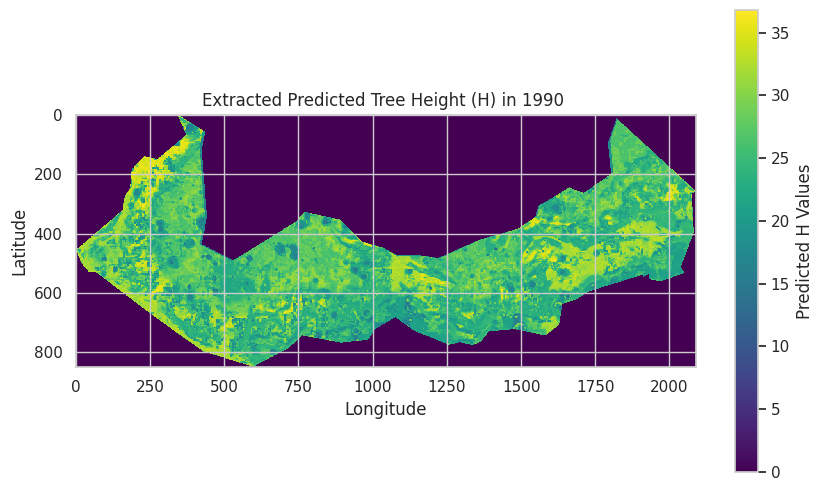

In [ ]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping

# Paths to files
raster_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1989_1990.tif"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
output_extracted_raster = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_1990_Masked.tif"

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)

# Open the raster and mask it using the geojson file
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
    out_meta = src.meta.copy()
    nodata_value = src.nodata  # Store NoData value

# Update metadata after cropping
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Save the masked raster
with rasterio.open(output_extracted_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("Extracted raster saved at:", output_extracted_raster)

# --- VISUALIZATION ---
# Mask NoData values
masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])

# Create an alpha transparency mask
alpha_mask = np.where(out_image[0] == nodata_value, 0, 1)

# Plot the masked raster
plt.figure(figsize=(10, 6))
plt.imshow(masked_data, cmap="viridis", interpolation="nearest", alpha=alpha_mask)
plt.colorbar(label="Predicted H Values")
plt.title("Extracted Predicted Tree Height (H) in 1990 ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


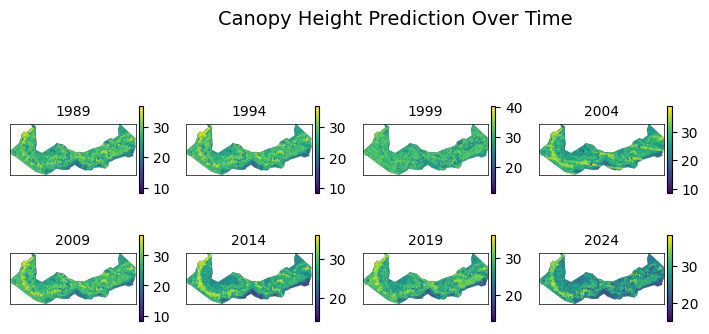

In [ ]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping
import os

# Base paths
base_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

# Years to loop through
years = [(y, y+1) for y in range(1989, 2025, 5)]  # (1989_1990, ..., 2024_2025)

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)
masked_rasters = []

# Process each raster
for start, end in years:
    year_str = f"{start}_{end}"
    raster_path = os.path.join(base_path, f"H_Predicted_{year_str}.tif")

    try:
        with rasterio.open(raster_path) as src:
            out_image, out_transform = rasterio.mask.mask(
                src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
            nodata_value = src.nodata
            masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])
            masked_rasters.append((year_str, masked_data))
    except Exception as e:
        print(f"Failed to process {raster_path}: {e}")

# --- PLOTTING SIDE BY SIDE ---
# --- PLOTTING SIDE BY SIDE WITH 4 PER ROW ---
# --- PLOTTING SIDE BY SIDE WITH 4 PER ROW (COMPACT LAYOUT) ---
cols = 4
rows = int(np.ceil(len(masked_rasters) / cols))

plt.figure(figsize=(cols * 2.0, rows * 2.0))

for idx, (year_str, data) in enumerate(masked_rasters):
    start_year = year_str.split('_')[0]  # Extract "1989" from "1989_1990"
    ax = plt.subplot(rows, cols, idx + 1)

    img = ax.imshow(data, cmap="viridis")
    ax.set_title(start_year, fontsize=10)

    # Show a frame around each plot
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['top'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)

    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.colorbar(img, ax=ax, shrink=0.4, pad=0.02)

plt.suptitle("Canopy Height Prediction Over Time", fontsize=14)

# Tighter layout and bring title closer
plt.tight_layout(rect=[0, 0, 0.90, 0.64])  # Was 0.92; increase to bring title closer
plt.subplots_adjust(top=0.90)  # Pull down the top margin (adjust as needed)

plt.show()




In [ ]:
import glob
import os
# Search for .tif files while excluding DEM and Slope
tif_files = [file for file in glob.glob(os.path.join(path5, '*.tif'))]

print("Filtered raster files for multicollinearity test:")
for file in tif_files:
    print(file)

Filtered raster files for multicollinearity test:
/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_2000.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_1995.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_1990.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_2010.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_2005.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_2020.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_2015.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_2024.tif


In [ ]:
import os
import glob

# Find all .tif files
tif_files = glob.glob(os.path.join(path5, '*.tif'))

# Rename files with double years
for file in tif_files:
    filename = os.path.basename(file)
    if '_' in filename:
        parts = filename.replace('.tif', '').split('_')
        # Check if filename has a year range (e.g., 1999_2000)
        for part in parts:
            if part.isdigit() and len(part) == 4:
                year_index = parts.index(part)
                if (year_index + 1 < len(parts)) and parts[year_index+1].isdigit():
                    new_year = parts[year_index+1]  # use the second year
                    new_name = f"H_Predicted_{new_year}.tif"
                    new_path = os.path.join(path5, new_name)
                    os.rename(file, new_path)
                    print(f"Renamed: {filename} → {new_name}")
                    break


Renamed: H_Predicted_1999_2000.tif → H_Predicted_2000.tif
Renamed: H_Predicted_1994_1995.tif → H_Predicted_1995.tif
Renamed: H_Predicted_1989_1990.tif → H_Predicted_1990.tif
Renamed: H_Predicted_2009_2010.tif → H_Predicted_2010.tif
Renamed: H_Predicted_2004_2005.tif → H_Predicted_2005.tif


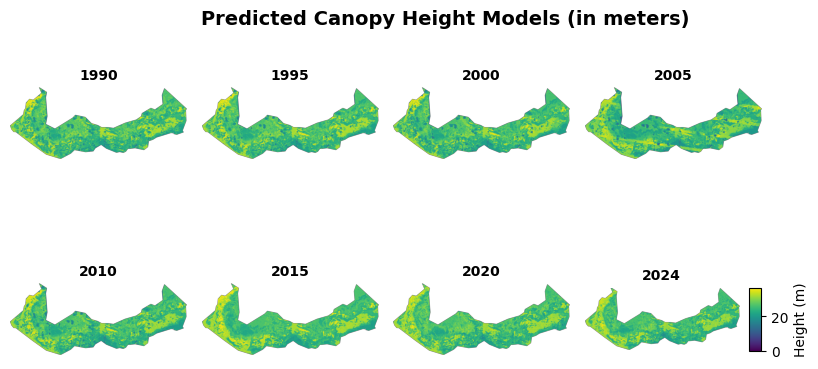

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np
import os

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(9, 6))
axes = axes.flatten()

possible_nodata_values = [0, -9999, -32768]
img_for_colorbar = None

for idx, file in enumerate(tif_files):
    with rasterio.open(file) as src:
        data = src.read(1)
        nodata = src.nodata if src.nodata is not None else -9999
        mask = ~np.isin(data, possible_nodata_values)
        data = np.where(mask, data, np.nan)

        # Extract year from filename
        filename = os.path.basename(file)
        year = filename.split('_')[-1].split('.')[0]

        img = axes[idx].imshow(data, cmap='viridis', vmin=0, vmax=np.nanmax(data))
        axes[idx].set_title(f"{year}", fontsize=10, fontweight='bold')
        axes[idx].axis('off')

        if img_for_colorbar is None:
            img_for_colorbar = img

# Add a large axis to hold the colorbar on the far right
from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="8%", pad=0.1)

# Add shared colorbar
cbar = plt.colorbar(img_for_colorbar, cax=cax)
cbar.set_label('Height (m)', fontsize=10)

# Overall title
plt.suptitle("Predicted Canopy Height Models (in meters)", fontsize=14, fontweight='bold', y=0.8)

# Layout
plt.tight_layout(rect=[0, 0, 0.92, 0.95])  # Extra space for suptitle
plt.show()


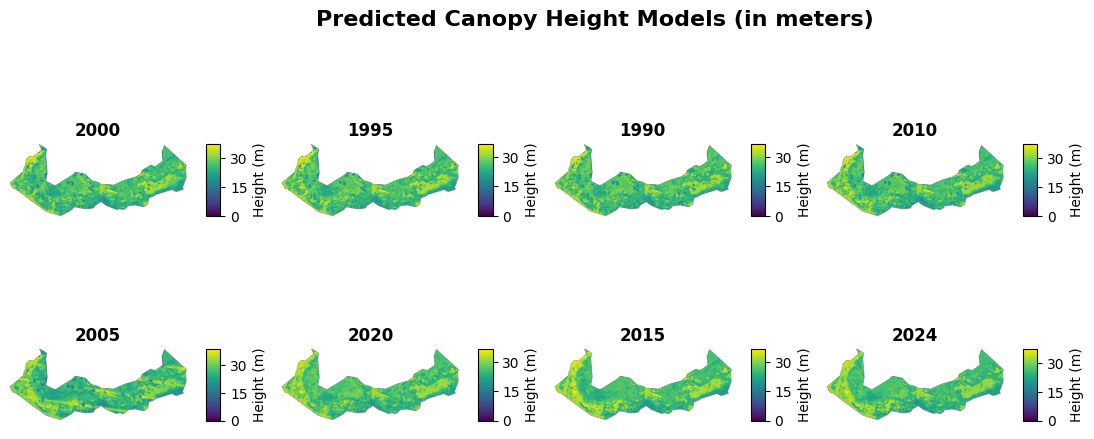

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np
import os
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))  # Increased size for better spacing
axes = axes.flatten()

possible_nodata_values = [0, -9999, -32768]

for idx, file in enumerate(tif_files):
    with rasterio.open(file) as src:
        data = src.read(1)
        nodata = src.nodata if src.nodata is not None else -9999
        mask = ~np.isin(data, possible_nodata_values)
        data = np.where(mask, data, np.nan)

        # Extract year from filename
        filename = os.path.basename(file)
        year = filename.split('_')[-1].split('.')[0]

        img = axes[idx].imshow(data, cmap='viridis', vmin=0, vmax=np.nanmax(data))
        axes[idx].set_title(f"{year}", fontsize=12, fontweight='bold')  # Slightly larger title font
        axes[idx].axis('off')

        # Add frame to each subplot by setting the spines explicitly
        for spine in axes[idx].spines.values():
            spine.set_edgecolor('black')  # Set the color of the frame to black
            spine.set_linewidth(3)  # Set the thickness of the frame

        # Create colorbar for each subplot with longer length
        divider = make_axes_locatable(axes[idx])
        cax = divider.append_axes("right", size="8%", pad=0.2)  # Increased size to 8% for longer colorbars
        cbar = plt.colorbar(img, cax=cax)

        # Set colorbar ticks at an interval of 5
        cbar.set_ticks(np.arange(0, np.nanmax(data)+1, 15))  # Set the ticks at intervals of 5
        cbar.set_label('Height (m)', fontsize=10)  # Slightly larger font for colorbar label

# Overall title
plt.suptitle("Predicted Canopy Height Models (in meters)", fontsize=16, fontweight='bold', y=0.9)  # Increased font size

# Layout
plt.tight_layout(rect=[0, 0, 0.92, 0.95])  # Extra space for suptitle
plt.show()


In [ ]:
import rasterio
import numpy as np
import pandas as pd

# List of raster paths
raster_paths = {
    "1990": "/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_1990.tif",
    "1995": "/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_1995.tif",
    "2000": "/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_2000.tif",
    "2005": "/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_2005.tif",
    "2010": "/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_2010.tif",
    "2015": "/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_2015.tif",
    "2020": "/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_2020.tif",
    "2024": "/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_2024.tif"
}


# Function to calculate stats
def calculate_stats(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        # Mask out no-data values
        data = np.ma.masked_equal(data, src.nodata)

        stats = {
            "Mean": data.mean(),
            "Min": data.min(),
            "Max": data.max(),
            "Std Dev": data.std()
        }
        return stats

# Store all stats
all_stats = []

# Loop through rasters and collect stats
for year, path in raster_paths.items():
    stats = calculate_stats(path)
    stats['Year'] = year  # Add year information
    all_stats.append(stats)

# Convert list of dicts into a DataFrame
df_stats = pd.DataFrame(all_stats)

# Rearranging columns
df_stats = df_stats[['Year', 'Mean', 'Min', 'Max', 'Std Dev']]

# Display the DataFrame
print(df_stats)

# (Optional) Save to CSV
output_csv = "/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM_summary_stats.csv"
df_stats.to_csv(output_csv, index=False)
print(f"\nSummary stats saved to: {output_csv}")


   Year       Mean        Min        Max   Std Dev
0  1990  25.947064   9.010533  36.804379  4.070601
1  1995  26.215388   8.646420  36.818573  4.063745
2  2000  26.017309   8.369284  37.209602  4.062718
3  2005  27.151151   8.619789  39.075798  4.612141
4  2010  26.360397   8.518221  37.389698  4.176607
5  2015  26.793258  16.027143  36.890434  3.846811
6  2020  26.709090  14.730939  37.051357  3.707260
7  2024  26.860066  14.713214  37.451180  3.807254

Summary stats saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/CHM_summary_stats.csv


In [ ]:
df_chm=df_stats
df_chm.head(10)

,Year,Mean,Min,Max,Std Dev
0,1990,25.947064,9.010533,36.804379,4.070601
1,1995,26.215388,8.646420,36.818573,4.063745
2,2000,26.017309,8.369284,37.209602,4.062718
3,2005,27.151151,8.619789,39.075798,4.612141
4,2010,26.360397,8.518221,37.389698,4.176607
5,2015,26.793258,16.027143,36.890434,3.846811
6,2020,26.709090,14.730939,37.051357,3.707260
7,2024,26.860066,14.713214,37.451180,3.807254


In [ ]:
df_stats.head(10)

,Year,Mean,Min,Max,Std Dev
0,1990,25.947064,9.010533,36.804379,4.070601
1,1995,26.215388,8.646420,36.818573,4.063745
2,2000,26.017309,8.369284,37.209602,4.062718
3,2005,27.151151,8.619789,39.075798,4.612141
4,2010,26.360397,8.518221,37.389698,4.176607
5,2015,26.793258,16.027143,36.890434,3.846811
6,2020,26.709090,14.730939,37.051357,3.707260
7,2024,26.860066,14.713214,37.451180,3.807254


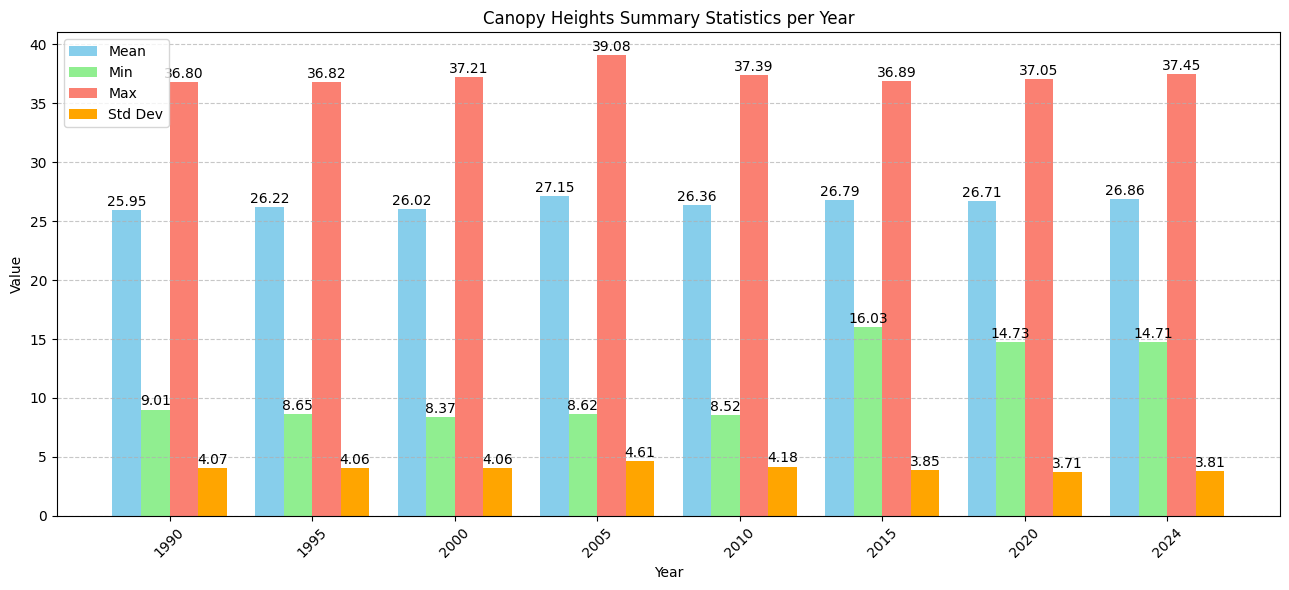

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set the figure size
plt.figure(figsize=(13, 6))

# Plot each statistic as a separate bar set
x = np.arange(len(df_stats['Year']))  # X axis labels (years)
width = 0.2  # Width of each bar

# Create bars
bars_mean = plt.bar(x - 1.5*width, df_stats['Mean'], width, label='Mean', color='skyblue')
bars_min = plt.bar(x - 0.5*width, df_stats['Min'], width, label='Min', color='lightgreen')
bars_max = plt.bar(x + 0.5*width, df_stats['Max'], width, label='Max', color='salmon')
bars_std = plt.bar(x + 1.5*width, df_stats['Std Dev'], width, label='Std Dev', color='orange')

# Add text on top of the bars
for bar in bars_mean:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

for bar in bars_min:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

for bar in bars_max:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

for bar in bars_std:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

# Labels and title
plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Canopy Heights Summary Statistics per Year')
plt.xticks(ticks=x, labels=df_stats['Year'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Layout tight and show
plt.tight_layout()
plt.show()


In [ ]:
import glob
import os
# Search for .tif files while excluding DEM and Slope
tif_files = [file for file in glob.glob(os.path.join(path6, '*.tif'))]

print("Filtered raster files for multicollinearity test:")
for file in tif_files:
    print(file)

Filtered raster files for multicollinearity test:
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2015.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2020.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2024.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_1995.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_1990.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2005.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2000.tif
/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2010.tif


In [ ]:
import rasterio
import numpy as np
import pandas as pd

# List of raster paths
raster_paths = {
    "1990": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_1990.tif",
    "1995": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_1995.tif",
    "2000": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2000.tif",
    "2005": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2005.tif",
    "2010": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2010.tif",
    "2015": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2015.tif",
    "2020": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2020.tif",
    "2024": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2024.tif"
}


# Function to calculate stats
def calculate_stats(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        # Mask out no-data values
        data = np.ma.masked_equal(data, src.nodata)

        stats = {
            "Mean": data.mean(),
            "Min": data.min(),
            "Max": data.max(),
            "Std Dev": data.std()
        }
        return stats

# Store all stats
all_stats = []

# Loop through rasters and collect stats
for year, path in raster_paths.items():
    stats = calculate_stats(path)
    stats['Year'] = year  # Add year information
    all_stats.append(stats)

# Convert list of dicts into a DataFrame
df_stats = pd.DataFrame(all_stats)

# Rearranging columns
df_stats = df_stats[['Year', 'Mean', 'Min', 'Max', 'Std Dev']]

# Display the DataFrame
print(df_stats)

# (Optional) Save to CSV
output_csv = "/content/drive/MyDrive/Kamatira Model Data/Outputs/dbh_raster_summary_stats.csv"
df_stats.to_csv(output_csv, index=False)
print(f"\nSummary stats saved to: {output_csv}")


   Year      Mean       Min       Max   Std Dev
0  1990  0.542285  0.373596  0.885097  0.057558
1  1995  0.539438  0.366674  0.822240  0.050810
2  2000  0.548519  0.374251  0.938944  0.059961
3  2005  0.522770  0.207278  0.893827  0.077086
4  2010  0.541626  0.364602  0.826410  0.051413
5  2015  0.590829  0.397653  0.926701  0.053545
6  2020  0.597764  0.391513  0.926701  0.057777
7  2024  0.594701  0.393770  0.926701  0.055596

Summary stats saved to: /content/drive/MyDrive/Kamatira Model Data/Outputs/dbh_raster_summary_stats.csv


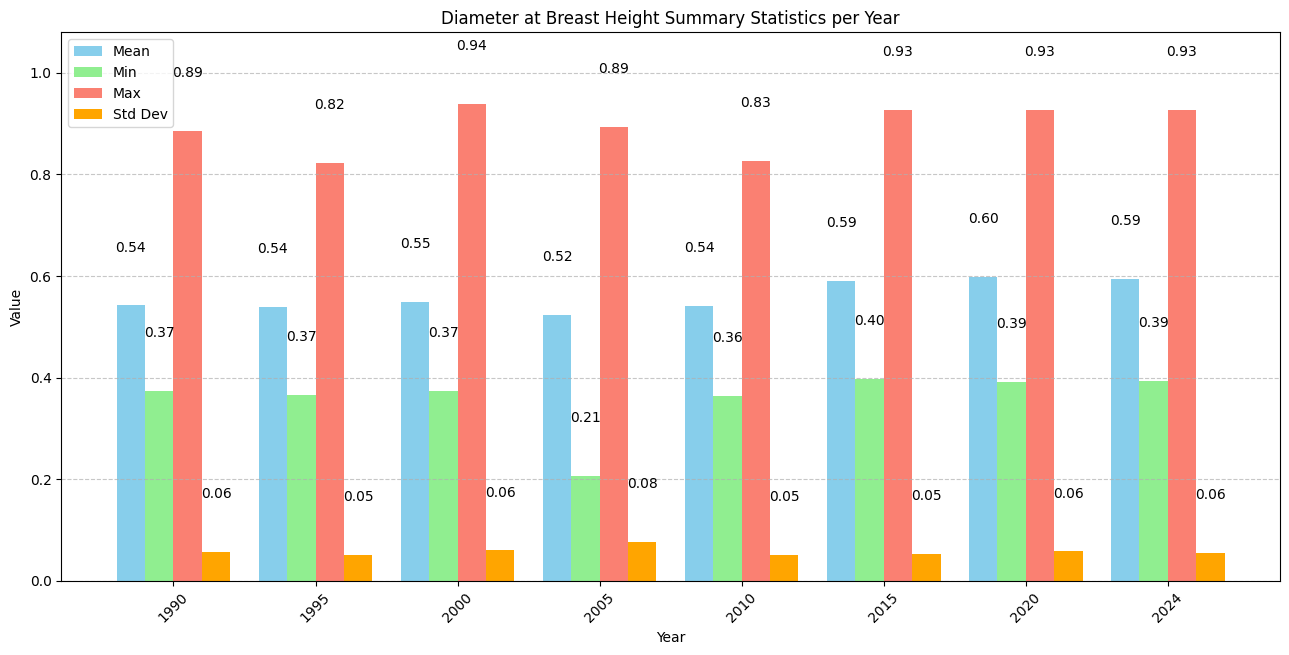

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set the figure size
plt.figure(figsize=(13, 7))

# Plot each statistic as a separate bar set
x = np.arange(len(df_stats['Year']))  # X axis labels (years)
width = 0.2  # Width of each bar

# Create bars
bars_mean = plt.bar(x - 1.5*width, df_stats['Mean'], width, label='Mean', color='skyblue')
bars_min = plt.bar(x - 0.5*width, df_stats['Min'], width, label='Min', color='lightgreen')
bars_max = plt.bar(x + 0.5*width, df_stats['Max'], width, label='Max', color='salmon')
bars_std = plt.bar(x + 1.5*width, df_stats['Std Dev'], width, label='Std Dev', color='orange')

# Compute the max value to adjust y-axis limit
all_heights = np.concatenate([
    df_stats['Mean'].values,
    df_stats['Min'].values,
    df_stats['Max'].values,
    df_stats['Std Dev'].values
])
y_max = np.max(all_heights)
plt.ylim(0, y_max * 1.15)  # Add 15% padding on top

# Add text on top of the bars
for bars in [bars_mean, bars_min, bars_max, bars_std]:
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}',
                 ha='center', va='bottom', fontsize=10)

# Labels and title
plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Diameter at Breast Height Summary Statistics per Year')
plt.xticks(ticks=x, labels=df_stats['Year'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout with more space for top labels
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


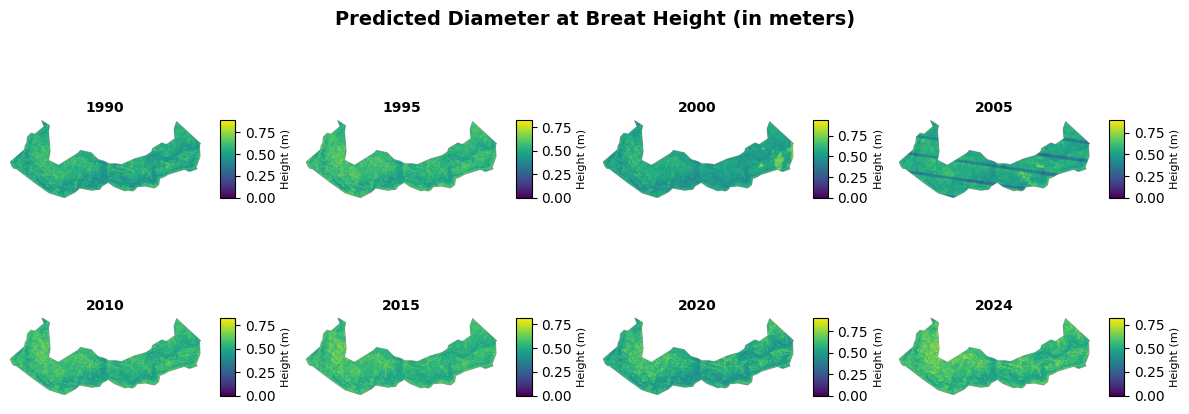

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np
import os
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Raster file paths
raster_paths = {
    "1990": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_1990.tif",
    "1995": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_1995.tif",
    "2000": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2000.tif",
    "2005": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2005.tif",
    "2010": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2010.tif",
    "2015": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2015.tif",
    "2020": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2020.tif",
    "2024": "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH/DBH_Predicted_2024.tif"
}


# Sort raster paths by year
sorted_years = sorted(raster_paths.keys())
tif_files = [raster_paths[year] for year in sorted_years]

# Setup plot
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
axes = axes.flatten()

possible_nodata_values = [0, -9999, -32768]

for idx, file in enumerate(tif_files):
    with rasterio.open(file) as src:
        data = src.read(1)
        nodata = src.nodata if src.nodata is not None else -9999
        mask = ~np.isin(data, possible_nodata_values)
        data = np.where(mask, data, np.nan)

        year = sorted_years[idx]
        img = axes[idx].imshow(data, cmap='viridis', vmin=0, vmax=np.nanmax(data))
        axes[idx].set_title(f"{year}", fontsize=10, fontweight='bold')
        axes[idx].axis('off')

        # Add frame
        for spine in axes[idx].spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(2)

        # Individual colorbars
        divider = make_axes_locatable(axes[idx])
        cax = divider.append_axes("right", size="8%", pad=0.2)
        cbar = plt.colorbar(img, cax=cax, ticks=np.arange(0, np.nanmax(data)+1, 0.25))
        cbar.set_label('Height (m)', fontsize=8)

# Overall title
plt.suptitle("Predicted Diameter at Breat Height (in meters)", fontsize=14, fontweight='bold', y=0.85)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


In [ ]:
df_dbh= df_stats
df_dbh.head(10)

,Year,Mean,Min,Max,Std Dev
0,1990,0.542285,0.373596,0.885097,0.057558
1,1995,0.539438,0.366674,0.822240,0.050810
2,2000,0.548519,0.374251,0.938944,0.059961
3,2005,0.522770,0.207278,0.893827,0.077086
4,2010,0.541626,0.364602,0.826410,0.051413
5,2015,0.590829,0.397653,0.926701,0.053545
6,2020,0.597764,0.391513,0.926701,0.057777
7,2024,0.594701,0.393770,0.926701,0.055596


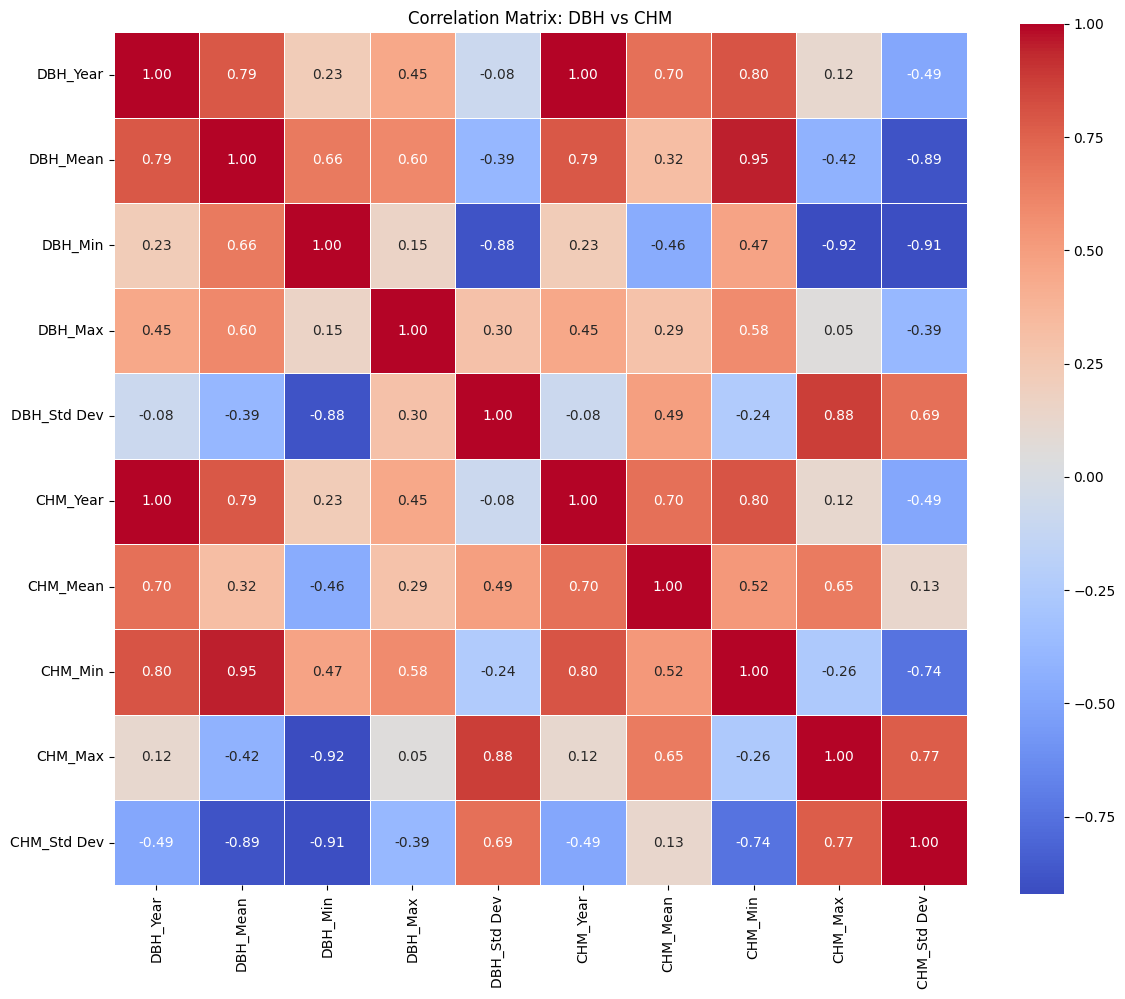

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combine into one DataFrame (prefix columns to distinguish)
df_dbh_prefixed = df_dbh.add_prefix('DBH_')
df_chm_prefixed = df_chm.add_prefix('CHM_')

# Concatenate and compute correlation
combined_df = pd.concat([df_dbh_prefixed, df_chm_prefixed], axis=1)
corr_matrix = combined_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Matrix: DBH vs CHM")
plt.tight_layout()
plt.show()


In [ ]:
path2 = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/tree_ground_truths.geojson'
import pandas as pd
import geopandas as gpd
# Load the GeoJSON file
gdf_gcps = gpd.read_file(path2)
gdf_gcps.head(2)
# # Add 'label' column with sequential val

,DBH,H,geometry
0,0.50,21.0312,POINT (35.14802 1.26881)
1,0.55,21.3360,POINT (35.14828 1.26873)


In [ ]:
gdf_gcps.head()

,DBH,H,geometry
0,0.50,21.0312,POINT (35.14802 1.26881)
1,0.55,21.3360,POINT (35.14828 1.26873)
2,0.54,20.7264,POINT (35.14832 1.2687)
3,0.56,14.3256,POINT (35.14862 1.26982)
4,0.60,21.3360,POINT (35.14867 1.26986)


In [ ]:
gdf_gcps = gdf_gcps.drop(columns=["DBH"])
gdf_gcps.head()

,H,geometry
0,21.0312,POINT (35.14802 1.26881)
1,21.3360,POINT (35.14828 1.26873)
2,20.7264,POINT (35.14832 1.2687)
3,14.3256,POINT (35.14862 1.26982)
4,21.3360,POINT (35.14867 1.26986)


In [ ]:
gdf_gcps.tail()

,H,geometry
223,2.1336,POINT (35.17271 1.26681)
224,13.7160,POINT (35.18311 1.27027)
225,17.6784,POINT (35.18322 1.27023)
226,21.6408,POINT (35.18277 1.27107)
227,20.7264,POINT (35.18099 1.27238)


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.sample import sample_gen
import pandas as pd

# Load your ground truth geodataframe (already done)
# gdf_gcps = ... (assumed already in your environment)

# Dictionary of rasters
raster_paths = {
    "1990": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_Masked_1990.tif",
    "1995": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_Masked_1995.tif",
    "2000": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_Masked_2000.tif",
    "2005": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_Masked_2005.tif",
    "2010": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_Masked_2010.tif",
    "2015": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2015_Masked.tif",
    "2020": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2020_Masked.tif",
    "2024": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_Masked.tif"
}

# Get the coordinates from the GCPs
coords = [(pt.x, pt.y) for pt in gdf_gcps.geometry]

# DataFrame to hold results
df_all = gdf_gcps.copy()

# Extract values from each raster
for year, path in raster_paths.items():
    with rasterio.open(path) as src:
        values = [val[0] if val[0] is not None else None for val in src.sample(coords)]
        df_all[f"Pred_{year}"] = values

# Show first few rows
print(df_all.head())


         H                  geometry  Pred_1990  Pred_1995  Pred_2000  \
0  21.0312  POINT (35.14802 1.26881)  32.448925  32.448925  32.499023   
1  21.3360  POINT (35.14828 1.26873)  32.456146  32.422077  32.461655   
2  20.7264   POINT (35.14832 1.2687)  32.456146  32.422077  32.461655   
3  14.3256  POINT (35.14862 1.26982)  30.583654  30.796816  30.897810   
4  21.3360  POINT (35.14867 1.26986)  31.764238  31.800926  31.952379   

   Pred_2005  Pred_2010  Pred_2015  Pred_2020  Pred_2024  
0  32.406536  32.406536  30.219593  30.219593  30.242701  
1  32.343063  32.343063  30.057598  30.057598  30.057598  
2  32.343063  32.343063  30.139435  30.139435  30.139435  
3  30.796816  30.796816  28.745893  28.579350  28.062145  
4  31.840546  31.840546  28.822319  29.358463  28.587950  


In [ ]:
df_all.head(5)

,H,geometry,Pred_1990,Pred_1995,Pred_2000,Pred_2005,Pred_2010,Pred_2015,Pred_2020,Pred_2024
0,21.0312,POINT (35.14802 1.26881),32.448925,32.448925,32.499023,32.406536,32.406536,30.219593,30.219593,30.242701
1,21.3360,POINT (35.14828 1.26873),32.456146,32.422077,32.461655,32.343063,32.343063,30.057598,30.057598,30.057598
2,20.7264,POINT (35.14832 1.2687),32.456146,32.422077,32.461655,32.343063,32.343063,30.139435,30.139435,30.139435
3,14.3256,POINT (35.14862 1.26982),30.583654,30.796816,30.897810,30.796816,30.796816,28.745893,28.579350,28.062145
4,21.3360,POINT (35.14867 1.26986),31.764238,31.800926,31.952379,31.840546,31.840546,28.822319,29.358463,28.587950


In [ ]:
from sklearn.metrics import mean_absolute_error

# Drop NA values to ensure clean comparison
df_valid = df_all.dropna(subset=["H", "Pred_2024"])

# Calculate MAE
mae_2024 = mean_absolute_error(df_valid["H"], df_valid["Pred_2024"])

print(f"Mean Absolute Error (MAE) for 2024: {mae_2024:.2f} meters")


Mean Absolute Error (MAE) for 2024: 16.71 meters


Model Fitting

In [ ]:
import geopandas as gpd
import pandas as pd

# Ensure geometry is active
gdf_rasters = gdf_rasters.set_geometry("geometry")

# Define bins and sample sizes
sample_spec = {
    (41, 50): 70,
    (31, 40): 50,
    (21, 30): 50
}

sampled_frames = []

# Loop over the specified bins and sample sizes
for (low, high), size in sample_spec.items():
    subset = gdf_rasters[(gdf_rasters['H'] >= low) & (gdf_rasters['H'] <= high)]
    sample = subset.sample(n=min(size, len(subset)), random_state=42)
    sampled_frames.append(sample[["H", "geometry"]])  # Only keep 'H' and 'geometry'

# Combine all samples into one GeoDataFrame
gdf_sampled = pd.concat(sampled_frames, ignore_index=True)
gdf_sampled = gpd.GeoDataFrame(gdf_sampled, geometry="geometry")

# Display sample count by H range
print("Sampled point distribution by H bins:")
print(gdf_sampled["H"].groupby(pd.cut(gdf_sampled["H"], bins=[20, 30, 40, 50])).count())

# Optional: Save to file
# gdf_sampled.to_file("sampled_points_by_H_range.geojson", driver="GeoJSON")


Sampled point distribution by H bins:
H
(20, 30]    50
(30, 40]    50
(40, 50]    70
Name: H, dtype: int64


<ipython-input-69-831f45bb3d21>:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(gdf_sampled["H"].groupby(pd.cut(gdf_sampled["H"], bins=[20, 30, 40, 50])).count())


In [ ]:
print(f"Number of points in gdf_gcps: {len(gdf_gcps)}")
print(f"Number of points in gdf_sampled: {len(gdf_sampled)}")


Number of points in gdf_gcps: 228
Number of points in gdf_sampled: 170


In [ ]:
import geopandas as gpd
import pandas as pd

# Ensure both GeoDataFrames have the same column names
gdf_gcps = gdf_gcps.rename(columns={"H": "H"})
gdf_sampled = gdf_sampled.rename(columns={"H": "H"})

# Concatenate the two GeoDataFrames
gdf_combined = pd.concat([gdf_gcps, gdf_sampled], ignore_index=True)

# Print results
print(gdf_combined)


             H                  geometry
0    21.031200  POINT (35.14802 1.26881)
1    21.336000  POINT (35.14828 1.26873)
2    20.726400   POINT (35.14832 1.2687)
3    14.325600  POINT (35.14862 1.26982)
4    21.336000  POINT (35.14867 1.26986)
..         ...                       ...
393  25.993334  POINT (35.16458 1.27206)
394  29.795334  POINT (35.20503 1.25778)
395  22.518932  POINT (35.16989 1.26058)
396  28.580767  POINT (35.21671 1.26564)
397  25.309999  POINT (35.20052 1.26256)

[398 rows x 2 columns]


In [ ]:
# Define output path
output_path = "/content/drive/MyDrive/Kamatira Model Data/shapeFiles/Kamatira_Forest_Fitted_heights.shp"
# Save as shapefile
gdf_combined.to_file(output_path)

print(f"Shapefile saved at: {output_path}")


Shapefile saved at: /content/drive/MyDrive/Kamatira Model Data/shapeFiles/Kamatira_Forest_Fitted_heights.shp


In [ ]:
# Load the ground truth data
path_ground_truth = "/content/drive/MyDrive/Kamatira Model Data/shapeFiles/Kamatira_Fitted_Dense_Points.shp"
gdf_points = gpd.read_file(path_ground_truth)
gdf_points.tail(5)
# Randomly sample 7000 points from gdf_points
gdf_sampled = gdf_points.sample(n=15000, random_state=42).reset_index(drop=True)
# Preview the result
gdf_sampled.head()


,OBJECTID,pointid,grid_code,geometry
0,2359979,2359979,8.47569,POINT (35.23654 1.27336)
1,3533058,3533058,23.60200,POINT (35.22842 1.27032)
2,981528,981528,21.67550,POINT (35.16359 1.27917)
3,6902747,6902747,18.58200,POINT (35.1641 1.26305)
4,5498634,5498634,22.67320,POINT (35.22047 1.26643)


In [ ]:
# Rename 'grid_code' to 'H'
gdf_points = gdf_points.rename(columns={"grid_code": "H"})

# Keep only 'H' and 'geometry' columns
gdf_points = gdf_points[["H", "geometry"]]

# Preview the cleaned data
print(gdf_points.head())

         H                  geometry
0  23.6410  POINT (35.16145 1.29123)
1  23.6436  POINT (35.16146 1.29123)
2  23.6490  POINT (35.16146 1.29122)
3  23.6516  POINT (35.16148 1.29122)
4  23.6546  POINT (35.16146 1.29121)


In [ ]:
print(gdf_points.head())

         H                  geometry
0  23.6410  POINT (35.16145 1.29123)
1  23.6436  POINT (35.16146 1.29123)
2  23.6490  POINT (35.16146 1.29122)
3  23.6516  POINT (35.16148 1.29122)
4  23.6546  POINT (35.16146 1.29121)


In [ ]:
import pandas as pd

# Define bins and labels
bins = [0, 10, 20, 30, 40, 50]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50']

# Create a new column 'H_bin' with binned data
gdf_points['H_bin'] = pd.cut(gdf_points['H'], bins=bins, labels=labels, right=True, include_lowest=True)

# Count the number of points in each bin
bin_counts = gdf_points['H_bin'].value_counts().sort_index()

# Display result
print("Point counts per H bin:")
print(bin_counts)


Point counts per H bin:
H_bin
0-10      663603
11-20    2985705
21-30    3767451
31-40    1263985
41-50     328608
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Define bins and labels
bins = [0, 10, 20, 30, 40, 50]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50']

# Create the 'H_bin' column
gdf_points['H_bin'] = pd.cut(gdf_points['H'], bins=bins, labels=labels, right=True, include_lowest=True)

# Define the target sample size for each bin
sample_sizes = {
    '0-10': 16_00,
    '11-20': 1_100,
    '21-30': 7_00,
    '31-40': 5_00,
    '41-50': 9_00  # Keep all
}

# Perform stratified sampling
sampled_dfs = []

for h_bin, group in gdf_points.groupby('H_bin'):
    target_n = sample_sizes.get(h_bin)
    if target_n is None or len(group) <= target_n:
        sampled = group
    else:
        sampled = group.sample(n=target_n, random_state=42)
    sampled_dfs.append(sampled)

# Combine all sampled bins
gdf_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Show final distribution
final_counts = gdf_sampled['H_bin'].value_counts().sort_index()
print("Final sampled counts per bin:")
print(final_counts)


<ipython-input-77-99320f3a195f>:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for h_bin, group in gdf_points.groupby('H_bin'):


Final sampled counts per bin:
H_bin
0-10     1600
11-20    1100
21-30     700
31-40     500
41-50     900
Name: count, dtype: int64


In [ ]:
# Randomly sample 7000 points from gdf_points
gdf_sampled = gdf_points.sample(n=15000, random_state=42).reset_index(drop=True)

# Preview the result
gdf_sampled.head()


,H,geometry,H_bin
0,8.47569,POINT (35.23654 1.27336),0-10
1,23.60200,POINT (35.22842 1.27032),21-30
2,21.67550,POINT (35.16359 1.27917),21-30
3,18.58200,POINT (35.1641 1.26305),11-20
4,22.67320,POINT (35.22047 1.26643),21-30


In [ ]:
gdf_points=gdf_sampled
gdf_points.head(10)

,H,geometry,H_bin
0,8.47569,POINT (35.23654 1.27336),0-10
1,23.60200,POINT (35.22842 1.27032),21-30
2,21.67550,POINT (35.16359 1.27917),21-30
3,18.58200,POINT (35.1641 1.26305),11-20
4,22.67320,POINT (35.22047 1.26643),21-30
5,23.39880,POINT (35.18675 1.27436),21-30
6,23.07620,POINT (35.22188 1.26528),21-30
7,19.92680,POINT (35.23665 1.26871),11-20
8,12.16030,POINT (35.21359 1.26049),11-20
9,25.32730,POINT (35.20936 1.26876),21-30


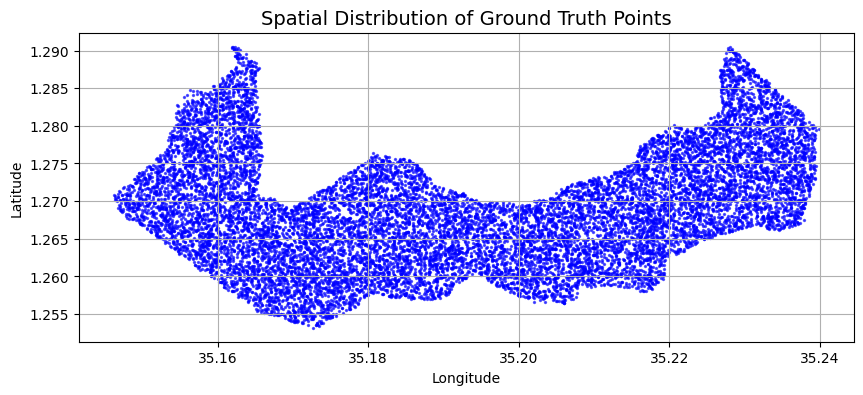

In [ ]:
import matplotlib.pyplot as plt

# Plot the points
fig, ax = plt.subplots(figsize=(10, 10))
gdf_points.plot(ax=ax, markersize=2, color='blue', alpha=0.6)
ax.set_title("Spatial Distribution of Ground Truth Points", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.grid(True)
plt.show()


In [ ]:
# Rename 'grid_code' to 'H'
gdf_points = gdf_points.rename(columns={"grid_code": "H"})

# Keep only 'H' and 'geometry' columns
gdf_points = gdf_points[["H", "geometry"]]

# Preview the cleaned data
print(gdf_points.head())

          H                  geometry
0   8.47569  POINT (35.23654 1.27336)
1  23.60200  POINT (35.22842 1.27032)
2  21.67550  POINT (35.16359 1.27917)
3  18.58200   POINT (35.1641 1.26305)
4  22.67320  POINT (35.22047 1.26643)


In [ ]:
# Define source raster paths
raster_paths = {
    "NDVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2024_2025_resampled.tif",
    "EVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/EVI_2024_2025_resampled.tif",
    # "RVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/RVI_2024_2025.tif",
    "Rain_24_25": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2024_2025_resampled.tif",
    "VH_24_25": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2024_2025_resampled.tif",
    "LAI_24_25": "/content/drive/MyDrive/Kamatira Model Data/LAI_2024_2025.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}


In [ ]:
import rasterio
import geopandas as gpd
import pandas as pd

def extract_raster_values(gdf, raster_paths):
    """
    Extracts raster values for given points from multiple raster files.
    """
    extracted_data = gdf.copy()

    for var, raster_path in raster_paths.items():
        with rasterio.open(raster_path) as src:
            values = list(src.sample([(point.x, point.y) for point in gdf.geometry]))
            extracted_data[var] = [val[0] if val is not None else None for val in values]

    # Ensure "H" column is retained
    if "H" in gdf.columns:
        extracted_data["H"] = gdf["H"]

    return extracted_data

# Extract data
gdf_rasters = extract_raster_values(gdf_points, raster_paths)

# Save the extracted data
output_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Revised_Coll_Kamatira_Extracted_Data.geojson"
gdf_rasters.to_file(output_path, driver="GeoJSON")

print("Extraction complete! Data saved at:", output_path)
print(gdf_rasters.head())  # Preview the first few rows

Extraction complete! Data saved at: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Revised_Coll_Kamatira_Extracted_Data.geojson
          H                  geometry  NDVI_24_25  EVI_24_25  Rain_24_25  \
0   8.47569  POINT (35.23654 1.27336)    0.593274   0.417637  554.083313   
1  23.60200  POINT (35.22842 1.27032)    0.689840   0.415653  519.666687   
2  21.67550  POINT (35.16359 1.27917)    0.704181   0.475096  583.947937   
3  18.58200   POINT (35.1641 1.26305)    0.673602   0.398431  516.666687   
4  22.67320  POINT (35.22047 1.26643)    0.614361   0.375103  370.083344   

    VH_24_25  LAI_24_25      Slope   DEM  
0 -14.532416   2.322819  16.753889  2319  
1 -17.575327   3.512944  13.832303  2287  
2 -17.381013   3.347522  21.993160  1946  
3 -14.715501   3.317775  23.637962  2070  
4 -13.721129   2.586586  10.456857  2273  


In [ ]:
gdf_rasters = gdf_rasters.dropna()
gdf_rasters.head(10)

,H,geometry,NDVI_24_25,EVI_24_25,Rain_24_25,VH_24_25,LAI_24_25,Slope,DEM
0,8.47569,POINT (35.23654 1.27336),0.593274,0.417637,554.083313,-14.532416,2.322819,16.753889,2319
1,23.60200,POINT (35.22842 1.27032),0.689840,0.415653,519.666687,-17.575327,3.512944,13.832303,2287
2,21.67550,POINT (35.16359 1.27917),0.704181,0.475096,583.947937,-17.381013,3.347522,21.993160,1946
3,18.58200,POINT (35.1641 1.26305),0.673602,0.398431,516.666687,-14.715501,3.317775,23.637962,2070
4,22.67320,POINT (35.22047 1.26643),0.614361,0.375103,370.083344,-13.721129,2.586586,10.456857,2273
5,23.39880,POINT (35.18675 1.27436),0.627555,0.328229,519.686401,-13.302893,2.961442,28.225693,2023
6,23.07620,POINT (35.22188 1.26528),0.586554,0.341375,441.666656,-14.574772,2.455318,19.672415,2320
7,19.92680,POINT (35.23665 1.26871),0.436597,0.264158,375.178802,-13.951248,1.574858,18.850546,2479
8,12.16030,POINT (35.21359 1.26049),0.434976,0.273872,575.583313,-22.937754,1.816369,24.700502,2380
9,25.32730,POINT (35.20936 1.26876),0.705860,0.442098,446.750000,-19.135466,3.351602,12.979351,1948


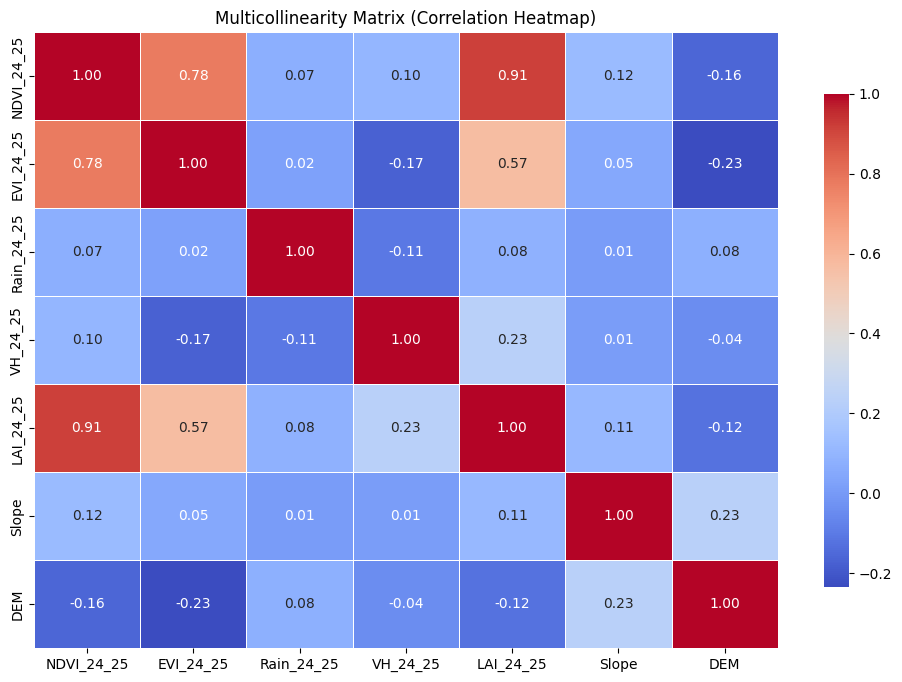

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the correlation matrix for all features in the DataFrame
corr_matrix = gdf_rasters.drop(columns=['geometry', 'H']).corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Multicollinearity Matrix (Correlation Heatmap)")
plt.show()


In [ ]:
gdf_final=gdf_rasters
gdf_rasters.head(10)

,H,geometry,NDVI_24_25,EVI_24_25,Rain_24_25,VH_24_25,LAI_24_25,Slope,DEM
0,8.47569,POINT (35.23654 1.27336),0.593274,0.417637,554.083313,-14.532416,2.322819,16.753889,2319
1,23.60200,POINT (35.22842 1.27032),0.689840,0.415653,519.666687,-17.575327,3.512944,13.832303,2287
2,21.67550,POINT (35.16359 1.27917),0.704181,0.475096,583.947937,-17.381013,3.347522,21.993160,1946
3,18.58200,POINT (35.1641 1.26305),0.673602,0.398431,516.666687,-14.715501,3.317775,23.637962,2070
4,22.67320,POINT (35.22047 1.26643),0.614361,0.375103,370.083344,-13.721129,2.586586,10.456857,2273
5,23.39880,POINT (35.18675 1.27436),0.627555,0.328229,519.686401,-13.302893,2.961442,28.225693,2023
6,23.07620,POINT (35.22188 1.26528),0.586554,0.341375,441.666656,-14.574772,2.455318,19.672415,2320
7,19.92680,POINT (35.23665 1.26871),0.436597,0.264158,375.178802,-13.951248,1.574858,18.850546,2479
8,12.16030,POINT (35.21359 1.26049),0.434976,0.273872,575.583313,-22.937754,1.816369,24.700502,2380
9,25.32730,POINT (35.20936 1.26876),0.705860,0.442098,446.750000,-19.135466,3.351602,12.979351,1948


In [ ]:
# Load the ground truth shapefile
path_ground_truth = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Revised_Coll_Kamatira_Extracted_Data.geojson"
gdf_points = gpd.read_file(path_ground_truth)

In [ ]:
gdf_final=gdf_points
gdf_final.head(10)

,H,NDVI_24_25,EVI_24_25,Rain_24_25,VH_24_25,LAI_24_25,Slope,DEM,geometry
0,8.47569,0.593274,0.417637,554.08331,-14.532416,2.322819,16.753889,2319,POINT (35.23654 1.27336)
1,23.60200,0.689840,0.415653,519.66669,-17.575327,3.512944,13.832303,2287,POINT (35.22842 1.27032)
2,21.67550,0.704181,0.475096,583.94794,-17.381013,3.347522,21.993160,1946,POINT (35.16359 1.27917)
3,18.58200,0.673602,0.398431,516.66669,-14.715501,3.317775,23.637962,2070,POINT (35.1641 1.26305)
4,22.67320,0.614361,0.375103,370.08334,-13.721129,2.586586,10.456857,2273,POINT (35.22047 1.26643)
5,23.39880,0.627555,0.328229,519.68640,-13.302893,2.961442,28.225693,2023,POINT (35.18675 1.27436)
6,23.07620,0.586554,0.341375,441.66666,-14.574772,2.455318,19.672415,2320,POINT (35.22188 1.26528)
7,19.92680,0.436597,0.264158,375.17880,-13.951248,1.574858,18.850546,2479,POINT (35.23665 1.26871)
8,12.16030,0.434976,0.273872,575.58331,-22.937754,1.816369,24.700502,2380,POINT (35.21359 1.26049)
9,25.32730,0.705860,0.442098,446.75000,-19.135466,3.351602,12.979351,1948,POINT (35.20936 1.26876)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Convert GeoDataFrame to DataFrame (drop geometry)
df = gdf_final.drop(columns=["geometry","VH_24_25"])

# Define input features (X) and target variable (y)
X = df[["NDVI_24_25", "EVI_24_25","LAI_24_25", "Rain_24_25",  "Slope","DEM"]]
y = df["H"]

# Handle missing values (if any)
X = X.fillna(X.mean())

# Split data into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=250, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R² Score: {r2}")

# Save the trained model (optional)
import joblib
joblib.dump(model, "/content/drive/MyDrive/Kamatira Model Data/Models/Revised_RandomForest_H_Model.pkl")
print("Model saved!")


Mean Absolute Error: 3.864004562688075
R² Score: 0.6240901832663441
Model saved!


In [ ]:
import rasterio
import numpy as np
import joblib
from rasterio.enums import Resampling

# Load the trained model
model = joblib.load('/content/drive/MyDrive/Kamatira Model Data/Models/Revised_RandomForest_H_Model.pkl')

# Define raster paths
raster_paths = {
    "NDVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2024_2025_resampled.tif",
    "EVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/EVI_2024_2025_resampled.tif",

    "Rain_24_25": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2024_2025_resampled.tif",
    # "VH_24_25": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2024_2025_resampled.tif",
    "LAI_24_25": "/content/drive/MyDrive/Kamatira Model Data/LAI_2024_2025.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}


# Use NDVI as the reference raster
with rasterio.open(raster_paths["NDVI_24_25"]) as ref:
    ref_meta = ref.meta.copy()  # Save metadata
    ref_height, ref_width = ref.height, ref.width
    ref_transform = ref.transform  # Get reference transform

# Function to resample raster
def resample_raster(src_path, ref_height, ref_width, ref_transform):
    with rasterio.open(src_path) as src:
        data = src.read(1, out_shape=(ref_height, ref_width), resampling=Resampling.bilinear)
        return data

# Read and resample rasters
bands = []
for key, path in raster_paths.items():
    bands.append(resample_raster(path, ref_height, ref_width, ref_transform))

# Convert to NumPy array and reshape
stacked_array = np.stack(bands, axis=0)  # Shape: (bands, height, width)
stacked_array_reshaped = stacked_array.reshape(len(raster_paths), -1).T  # Shape: (pixels, bands)

# Predict H values using the trained model
H_predictions = model.predict(stacked_array_reshaped)

# Reshape predictions back to raster format
H_raster = H_predictions.reshape(ref_height, ref_width)

# Save the predicted raster
ref_meta.update(dtype=rasterio.float32, count=1)

output_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_2025.tif"
with rasterio.open(output_path, "w", **ref_meta) as dst:
    dst.write(H_raster.astype(rasterio.float32), 1)

print(f"Prediction completed! Raster saved at: {output_path}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Prediction completed! Raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_2025.tif


Extracted raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_Masked.tif


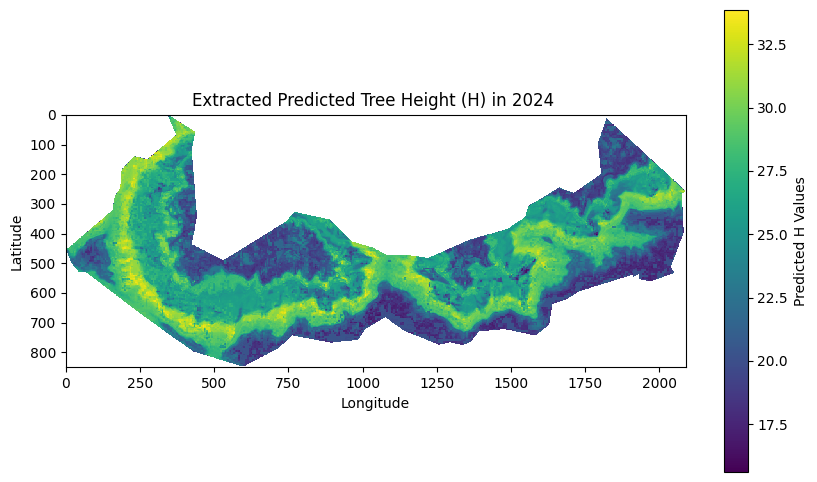

In [ ]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping

# Paths to files
raster_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_2025.tif"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
output_extracted_raster = "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_Masked.tif"

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)

# Open the raster and mask it using the geojson file
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
    out_meta = src.meta.copy()
    nodata_value = src.nodata  # Store NoData value

# Update metadata after cropping
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Save the masked raster
with rasterio.open(output_extracted_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("Extracted raster saved at:", output_extracted_raster)

# --- VISUALIZATION ---
# Mask NoData values
masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])

# Create an alpha transparency mask
alpha_mask = np.where(out_image[0] == nodata_value, 0, 1)

# Plot the masked raster
plt.figure(figsize=(10, 6))
plt.imshow(masked_data, cmap="viridis", interpolation="nearest", alpha=alpha_mask)
plt.colorbar(label="Predicted H Values")
plt.title("Extracted Predicted Tree Height (H) in 2024 ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.sample import sample_gen
import pandas as pd

# Load your ground truth geodataframe (already done)
# gdf_gcps = ... (assumed already in your environment)

# Dictionary of rasters
raster_paths = {

    "2024": "/content/drive/MyDrive/Kamatira Model Data/Outputs/H_Predicted_2024_Masked.tif"
}

# Get the coordinates from the GCPs
coords = [(pt.x, pt.y) for pt in gdf_gcps.geometry]

# DataFrame to hold results
df_all = gdf_gcps.copy()

# Extract values from each raster
for year, path in raster_paths.items():
    with rasterio.open(path) as src:
        values = [val[0] if val[0] is not None else None for val in src.sample(coords)]
        df_all[f"Pred_{year}"] = values

# Show first few rows
print(df_all.tail())


           H                  geometry  Pred_2024
223   2.1336  POINT (35.17271 1.26681)  22.643761
224  13.7160  POINT (35.18311 1.27027)  18.829908
225  17.6784  POINT (35.18322 1.27023)  19.531696
226  21.6408  POINT (35.18277 1.27107)  19.321722
227  20.7264  POINT (35.18099 1.27238)  23.557617


In [ ]:
from sklearn.metrics import mean_absolute_error

# Drop NA values to ensure clean comparison
df_valid = df_all.dropna(subset=["H", "Pred_2024"])

# Calculate MAE
mae_2024 = mean_absolute_error(df_valid["H"], df_valid["Pred_2024"])

print(f"Mean Absolute Error (MAE) for 2024: {mae_2024:.2f} meters")


Mean Absolute Error (MAE) for 2024: 12.00 meters


In [ ]:
mean_actual = df_valid["H"].mean()
mean_predicted = df_valid["Pred_2024"].mean()

print(f"Average Actual Height (H): {mean_actual:.2f} meters")
print(f"Average Predicted Height (Pred_2024): {mean_predicted:.2f} meters")


Average Actual Height (H): 12.39 meters
Average Predicted Height (Pred_2024): 23.07 meters


In [ ]:
# Compute IQR bounds for H
Q1_H = df_valid["H"].quantile(0.25)
Q3_H = df_valid["H"].quantile(0.75)
IQR_H = Q3_H - Q1_H
lower_H = Q1_H - 1.5 * IQR_H
upper_H = Q3_H + 1.5 * IQR_H

# Compute IQR bounds for Pred_2024
Q1_P = df_valid["Pred_2024"].quantile(0.25)
Q3_P = df_valid["Pred_2024"].quantile(0.75)
IQR_P = Q3_P - Q1_P
lower_P = Q1_P - 1.5 * IQR_P
upper_P = Q3_P + 1.5 * IQR_P

# Filter out outliers in both H and Pred_2024
df_filtered = df_valid[
    (df_valid["H"] >= lower_H) & (df_valid["H"] <= upper_H) &
    (df_valid["Pred_2024"] >= lower_P) & (df_valid["Pred_2024"] <= upper_P)
]

# Compute the means
mean_actual = df_filtered["H"].mean()
mean_predicted = df_filtered["Pred_2024"].mean()

print(f"Average Actual Height (H) without outliers: {mean_actual:.2f} meters")
print(f"Average Predicted Height (Pred_2024) without outliers: {mean_predicted:.2f} meters")


Average Actual Height (H) without outliers: 12.04 meters
Average Predicted Height (Pred_2024) without outliers: 23.37 meters


In [ ]:
# Recalculate bounds using IQR
Q1 = df_valid["H"].quantile(0.25)
Q3 = df_valid["H"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Exclude outliers
df_no_outliers = df_valid[(df_valid["H"] >= lower_bound) & (df_valid["H"] <= upper_bound)]

# Compute means without outliers
mean_actual = df_no_outliers["H"].mean()
mean_predicted = df_no_outliers["Pred_2024"].mean()

print(f"Average Actual Height (H) without outliers: {mean_actual:.2f} meters")
print(f"Average Predicted Height (Pred_2024) without outliers: {mean_predicted:.2f} meters")


Average Actual Height (H) without outliers: 12.20 meters
Average Predicted Height (Pred_2024) without outliers: 23.06 meters


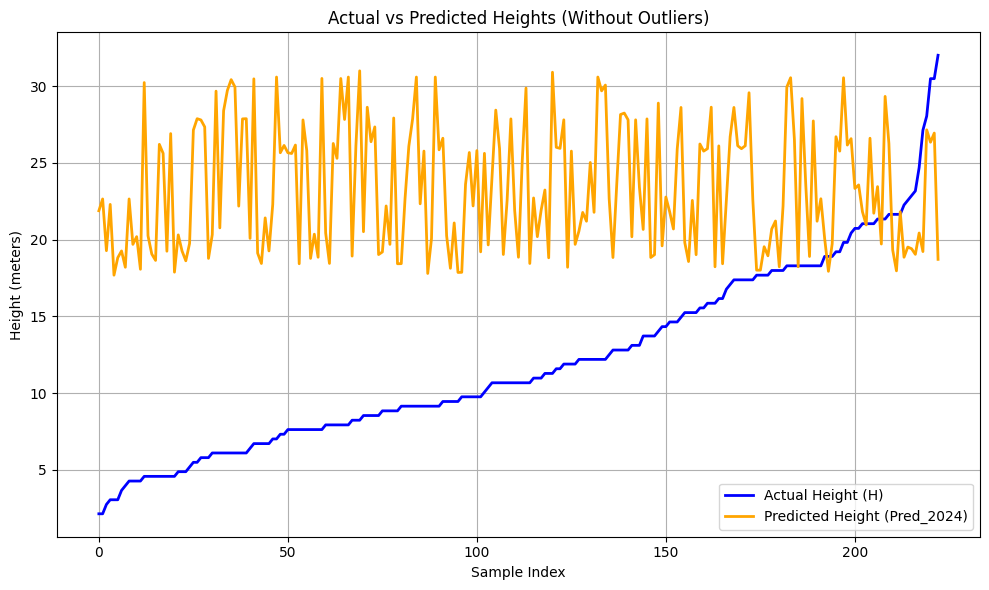

In [ ]:
import matplotlib.pyplot as plt

# Sort the filtered dataframe for a meaningful line plot
df_sorted = df_filtered.sort_values(by="H").reset_index(drop=True)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(df_sorted.index, df_sorted["H"], label="Actual Height (H)", color="blue", linewidth=2)
plt.plot(df_sorted.index, df_sorted["Pred_2024"], label="Predicted Height (Pred_2024)", color="orange", linewidth=2)

# Labeling
plt.title("Actual vs Predicted Heights (Without Outliers)")
plt.xlabel("Sample Index")
plt.ylabel("Height (meters)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
